# Trabajo individual: Regresión
___
- Universidad Carlos III de Madrid, 4º Curso
- Asignatura: Métodos estadísticos en minería de datos
- Autor: Miriam Gómez Arias
___

# 1. Introduccón

El conjunto de datos seleccionado corresponde al problema **House Prices – Advanced Regression Techniques**, disponible en Kaggle. Dichos datos resultan especialmente adecuados para los objetivos académicos del trabajo, ya que permite aplicar de manera completa y estructurada todas las fases del proceso de minería de datos estudiadas en la asignatura.

El conjunto incluye más de 70 variables predictoras de naturaleza heterogénea (características estructurales, materiales, calidad de la vivienda, información del entorno, años de construcción y remodelaciones, entre otras) además de más de 1.400 observaciones. Esta combinación garantiza suficiente variedad y volumen para aplicar técnicas exploratorias, no supervisadas y supervisadas con rigor.

Desde una perspectiva temática, el problema es de gran relevancia socioeconómica: predecir el precio de venta de una vivienda. El mercado inmobiliario está influido por múltiples factores y presenta relaciones no lineales, lo que lo convierte en un escenario idóneo para explorar técnicas avanzadas de modelado. Este contexto aporta valor práctico y analítico, permitiendo examinar el papel de distintas características en la valoración de una propiedad y ofreciendo un puente entre análisis académico y aplicaciones reales en tasación, inversión o evaluación inmobiliaria.

Este dataset encaja especialmente bien con los objetivos del trabajo individual, ya que permite desarrollar:

- Procesamiento y visualización avanzados, gracias a la mezcla de variables numéricas, categóricas y ordinales.  
- Técnicas de reducción de dimensionalidad (PCA), tanto para visualización como para evaluar la compresión de información en modelos predictivos.  
- Métodos de clustering, que facilitan la identificación de segmentos naturales del mercado inmobiliario y el análisis comparativo entre grupos.  
- Modelos supervisados como árboles de regresión y redes neuronales, posibilitando comparar interpretabilidad, rendimiento y complejidad.  
- Evaluación crítica del proceso completo, justificando decisiones metodológicas y analizando el valor real de los modelos.

En cuanto a las hipótesis de estudio:

1. Las variables asociadas a la calidad global y al estado de la vivienda (como OverallQual, KitchenQual o GrLivArea) tienen una influencia mayor en el precio de venta que variables puramente estructurales o de tamaño, reflejando que el mercado valora especialmente la calidad percibida.

2. La reducción de dimensionalidad mediante PCA permite conservar la mayor parte de la información relevante del conjunto de datos, manteniendo un alto porcentaje de varianza explicada y facilitando el uso de técnicas de clustering sin una pérdida sustancial de información.

3. Los métodos de clustering no supervisados (K-Means) identifican segmentos diferenciados del mercado inmobiliario, correspondientes a viviendas de distinto perfil económico, lo que sugiere que el mercado no es homogéneo.

4. La regresión aplicada de forma independiente por clúster mejora la comprensión del comportamiento del precio dentro de cada segmento, aunque su rendimiento puede variar significativamente entre grupos debido a diferencias internas en la estructura de los datos.

5. Los modelos supervisados más complejos, como las redes neuronales, ofrecen un mayor poder predictivo que los modelos más simples (árboles de decisión o regresión por clúster), a costa de una menor interpretabilidad.

Este conjunto de datos no solo es adecuado por su contenido, sino también por lo que permite demostrar dentro del trabajo:

- la integración de diversas técnicas de minería de datos;  
- la importancia de justificar cada decisión metodológica;  
- el análisis crítico del rendimiento y la interpretabilidad de los modelos;  
- la aplicación práctica de los métodos estudiados en un caso realista y lo bastante complejo.

En conjunto, constituye un marco sólido y completo para desarrollar todas las etapas requeridas en el trabajo, desde el preprocesamiento hasta la comparación de modelos avanzados, aportando conclusiones bien fundamentadas y contextualizadas.

# 2. Manipulación y visualización de datos

## 2.1 Carga y exploración inicial del dataset

En esta primera fase del trabajo se llevó a cabo la carga del dataset correspondiente:

In [2]:
import pandas as pd

ruta = r"C:\Users\miria\OneDrive\Escritorio\trabajo\train.csv"
df = pd.read_csv(ruta)

print(df.head())
print(df.shape)
print(df.dtypes)
print(df.info(), "\n")
num_duplicados = df.duplicated().sum()
print( num_duplicados)

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

Una vez conocidas las variables vamos a presentarlas y crearemos una leyenda que nos ayudara a entender e interpretar el análisis a lo largo de todo el trabajo:

- **Id**: Identificador único de cada registro.
- **MSSubClass**: Clase del tipo de construcción.
- **MSZoning**: Clasificación general de zonificación.
- **LotFrontage**: Pies lineales de calle conectados a la propiedad.
- **LotArea**: Tamaño del lote en pies cuadrados.
- **Street**: Tipo de acceso por carretera.
- **Alley**: Tipo de acceso por callejón.
- **LotShape**: Forma general del lote.
- **LandContour**: Llanura o nivelación del terreno.
- **Utilities**: Servicios disponibles.
- **LotConfig**: Configuración del lote.
- **LandSlope**: Pendiente del terreno.
- **Neighborhood**: Ubicación física dentro de la ciudad de Ames.
- **Condition1**: Proximidad a carretera principal o ferrocarril.
- **Condition2**: Segunda proximidad a carretera principal o ferrocarril.
- **BldgType**: Tipo de edificio o vivienda.
- **HouseStyle**: Estilo arquitectónico de la vivienda.
- **OverallQual**: Calidad general del material y acabado.
- **OverallCond**: Condición general del inmueble.
- **YearBuilt**: Año original de construcción.
- **YearRemodAdd**: Año de la última remodelación.
- **RoofStyle**: Tipo de tejado.
- **RoofMatl**: Material del tejado.
- **Exterior1st**: Revestimiento exterior principal.
- **Exterior2nd**: Segundo revestimiento exterior.
- **MasVnrType**: Tipo de revestimiento de mampostería.
- **MasVnrArea**: Área de revestimiento de mampostería (pies cuadrados).
- **ExterQual**: Calidad del material exterior.
- **ExterCond**: Estado del material exterior.
- **Foundation**: Tipo de cimientos.
- **BsmtQual**: Altura del sótano.
- **BsmtCond**: Estado general del sótano.
- **BsmtExposure**: Exposición o salida a nivel del jardín.
- **BsmtFinType1**: Calidad del área terminada tipo 1 del sótano.
- **BsmtFinSF1**: Área terminada tipo 1 (pies cuadrados).
- **BsmtFinType2**: Calidad del área terminada tipo 2 del sótano.
- **BsmtFinSF2**: Área terminada tipo 2 (pies cuadrados).
- **BsmtUnfSF**: Área sin terminar del sótano (pies cuadrados).
- **TotalBsmtSF**: Área total del sótano (pies cuadrados).
- **Heating**: Tipo de calefacción.
- **HeatingQC**: Calidad y estado del sistema de calefacción.
- **CentralAir**: Aire acondicionado central.
- **Electrical**: Sistema eléctrico.
- **1stFlrSF**: Superficie del primer piso (pies cuadrados).
- **2ndFlrSF**: Superficie del segundo piso (pies cuadrados).
- **LowQualFinSF**: Superficie terminada de baja calidad (pies cuadrados).
- **GrLivArea**: Superficie habitable sobre el nivel del suelo (pies cuadrados).
- **BsmtFullBath**: Baños completos en el sótano.
- **BsmtHalfBath**: Medios baños en el sótano.
- **FullBath**: Baños completos sobre el nivel del suelo.
- **HalfBath**: Medios baños sobre el nivel del suelo.
- **BedroomAbvGr**: Dormitorios sobre el nivel del sótano.
- **KitchenAbvGr**: Número de cocinas.
- **KitchenQual**: Calidad de la cocina.
- **TotRmsAbvGrd**: Total de habitaciones sobre el nivel del suelo (sin baños).
- **Functional**: Nivel de funcionalidad general del hogar.
- **Fireplaces**: Número de chimeneas.
- **FireplaceQu**: Calidad de la chimenea.
- **GarageType**: Ubicación del garaje.
- **GarageYrBlt**: Año de construcción del garaje.
- **GarageFinish**: Acabado interior del garaje.
- **GarageCars**: Capacidad del garaje (número de autos).
- **GarageArea**: Área del garaje (pies cuadrados).
- **GarageQual**: Calidad del garaje.
- **GarageCond**: Condición del garaje.
- **PavedDrive**: Tipo de entrada pavimentada.
- **WoodDeckSF**: Superficie de terraza de madera (pies cuadrados).
- **OpenPorchSF**: Área de porche abierto (pies cuadrados).
- **EnclosedPorch**: Área de porche cerrado (pies cuadrados).
- **3SsnPorch**: Porche de tres estaciones (pies cuadrados).
- **ScreenPorch**: Porche con mosquitera (pies cuadrados).
- **PoolArea**: Área de piscina (pies cuadrados).
- **PoolQC**: Calidad de la piscina.
- **Fence**: Calidad de la valla.
- **MiscFeature**: Característica miscelánea adicional no categorizada.
- **MiscVal**: Valor de características misceláneas.
- **MoSold**: Mes en que se vendió la propiedad.
- **YrSold**: Año en que se vendió la propiedad.
- **SaleType**: Tipo de venta.
- **SaleCondition**: Condición de venta.
- **SalePrice**: Precio de venta de la propiedad en dólares (variable objetivo).

El conjunto de datos analizado contiene 1460 observaciones y 81 variables, lo que indica un dataset amplio y diverso. La vista de las primeras cinco filas revela propiedades ubicadas predominantemente en zonas residenciales de alta calidad (MSZoning = RL) y con acceso pavimentado (Street = Pave). Las dimensiones del lote varían considerablemente, con superficies que van desde 8450 hasta más de 14000 pies cuadrados en los primeros registros, lo que sugiere heterogeneidad en el tamaño y la distribución de los terrenos. Del mismo modo, la variable LotFrontage, que mide los pies lineales conectados a la calle, ya evidencia valores faltantes posteriores (no en las primeras filas), un patrón que confirma más adelante la existencia de 1201 valores no nulos, por lo que aproximadamente un 18% de esta variable está ausente.

El análisis del tipo de datos confirma que el dataset está compuesto por una mezcla equilibrada entre variables numéricas (int64 y float64) y categóricas (object). En total, se identifican 35 variables numéricas, 3 de tipo float (que incluyen métricas continuas como LotFrontage y MasVnrArea) y 43 variables categóricas, reflejando una estructura rica que captura múltiples aspectos físicos, estructurales y administrativos de las viviendas.

También destacan las columnas con altos niveles de datos faltantes: Alley (91 valores no nulos), PoolQC (solo 7 registros con información), MiscFeature, Fence, FireplaceQu, entre otras. Estas variables, relacionadas con características menos comunes como callejones, piscinas o elementos misceláneos, muestran patrones de ausencia que pueden deberse tanto a no disponibilidad real (por ejemplo, casas sin piscina) como a registros perdidos. Este nivel de ausencia sugiere que será necesario aplicar estrategias de imputación adecuadas o considerar la eliminación de dichas variables según la relevancia del modelo.

Las variables numéricas esenciales para el análisis estructural (como OverallQual, YearBuilt, GrLivArea, GarageCars y SalePrice) están completas, lo cual es una ventaja significativa para tareas de modelado predictivo, ya que estas suelen ser las variables con mayor poder explicativo en modelos de regresión inmobiliaria. Además, la variable objetivo SalePrice no contiene valores faltantes y presenta una distribución inicial coherente con diferentes tipos de vivienda, mostrando precios desde los 140,000 hasta 250,000 dólares en los ejemplos iniciales.

Finalmente, el informe de info() confirma la correcta estructura del DataFrame, un uso moderado de memoria (aprox. 924 KB), y una distribución equilibrada de variables que permitirá aplicar tanto análisis exploratorios como modelos predictivos complejos. En general, se trata de un dataset robusto, variado y con suficientes elementos para construir modelos de valoración inmobiliaria confiables, siempre y cuando se aborde adecuadamente la imputación y manejo de las variables con alta tasa de datos faltantes.


## 2.2 Manipulación y limpieza

Una vez introducidos nuestros datos podemos pasar con la manipulación y limpieza de los mismos.

In [3]:
porcentaje_na = df.isna().mean() * 100
print(porcentaje_na.sort_values(ascending=False))
umbral = 0.4 
df_limpiado = df.loc[:, df.isna().mean() <= umbral]
print(f"Nuevo tamaño del dataset: {df_limpiado.shape}")

PoolQC         99.520548
MiscFeature    96.301370
Alley          93.767123
Fence          80.753425
MasVnrType     59.726027
                 ...    
ExterQual       0.000000
Exterior2nd     0.000000
Exterior1st     0.000000
RoofMatl        0.000000
SalePrice       0.000000
Length: 81, dtype: float64
Nuevo tamaño del dataset: (1460, 75)


Este código primero, calcula el número y porcentaje de valores faltantes por columna, ordenándolos de mayor a menor. Luego, identifica y elimina automáticamente aquellas columnas cuyo porcentaje de valores nulos supera un umbral definido del 40%, mostrando un reporte detallado de las columnas afectadas. Finalmente, devuelve el DataFrame limpio junto con el análisis completo y la lista de columnas eliminadas, proporcionando así una limpieza inicial eficiente que prioriza la eliminación de variables con alta tasa de datos ausentes.

El análisis revela que el dataset presenta seis columnas con más del 40% de valores nulos: PoolQC (99.5%), MiscFeature (96.3%), Alley (93.8%), Fence (80.8%) y MasVnrType (59.7%) y FireplaceQu (47.3% de nulos). Estas variables, relacionadas con características opcionales como piscinas, elementos misceláneos, callejones, vallas, revestimientos de mampostería y chimeneas, muestran tasas de ausencia tan elevadas que su utilidad para el modelado predictivo sería limitada. Tras su eliminación, el dataset se reduce de 81 a 75 columnas, conservando 1460 observaciones. Esta decisión preserva la integridad del conjunto de datos mientras elimina ruido potencial.

In [4]:
from sklearn.impute import SimpleImputer
df_limpiado = df_limpiado.copy()
num_cols = df_limpiado.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df_limpiado.select_dtypes(include=['object', 'category']).columns

imputer_num = SimpleImputer(strategy='median')
df_limpiado[num_cols] = imputer_num.fit_transform(df_limpiado[num_cols])

imputer_cat = SimpleImputer(strategy='most_frequent')
df_limpiado[cat_cols] = imputer_cat.fit_transform(df_limpiado[cat_cols])

df = df_limpiado.copy()

Este fragmento de código SimpleImputer de sklearn para limpiar un DataFrame rellenando los valores faltantes. Primero se hace una copia del DataFrame original para evitar modificarlo directamente. Luego se identifican las columnas numéricas (int64 y float64) y categóricas (object o category). Para las columnas numéricas, se crea un imputador que reemplaza los valores faltantes con la mediana de cada columna, mientras que para las columnas categóricas se usa un imputador que rellena los valores faltantes con la categoría más frecuente. Se utilizan estrategias distintas para columnas numéricas y categóricas porque los datos tienen naturaleza diferente. En las columnas numéricas, rellenar los valores faltantes con la mediana evita que los valores extremos distorsionen el promedio y mantiene la distribución central de los datos. En las columnas categóricas, se usa la categoría más frecuente porque no tiene sentido calcular un promedio; en cambio, asignar la categoría que aparece con mayor frecuencia permite conservar la tendencia más representativa de la variable.

               Cantidad_Outliers
EnclosedPorch                208
BsmtFinSF2                   167
OverallCond                  125
ScreenPorch                  116
LotFrontage                  106
MSSubClass                   103
MasVnrArea                    98
BsmtHalfBath                  82
OpenPorchSF                   77
LotArea                       69
KitchenAbvGr                  68
TotalBsmtSF                   61
SalePrice                     61
MiscVal                       52
BedroomAbvGr                  35
WoodDeckSF                    32
GrLivArea                     31
TotRmsAbvGrd                  30
BsmtUnfSF                     29
LowQualFinSF                  26
3SsnPorch                     24
GarageArea                    21
1stFlrSF                      20
PoolArea                       7
BsmtFinSF1                     7
YearBuilt                      7
Fireplaces                     5
GarageCars                     5
2ndFlrSF                       2
OverallQua

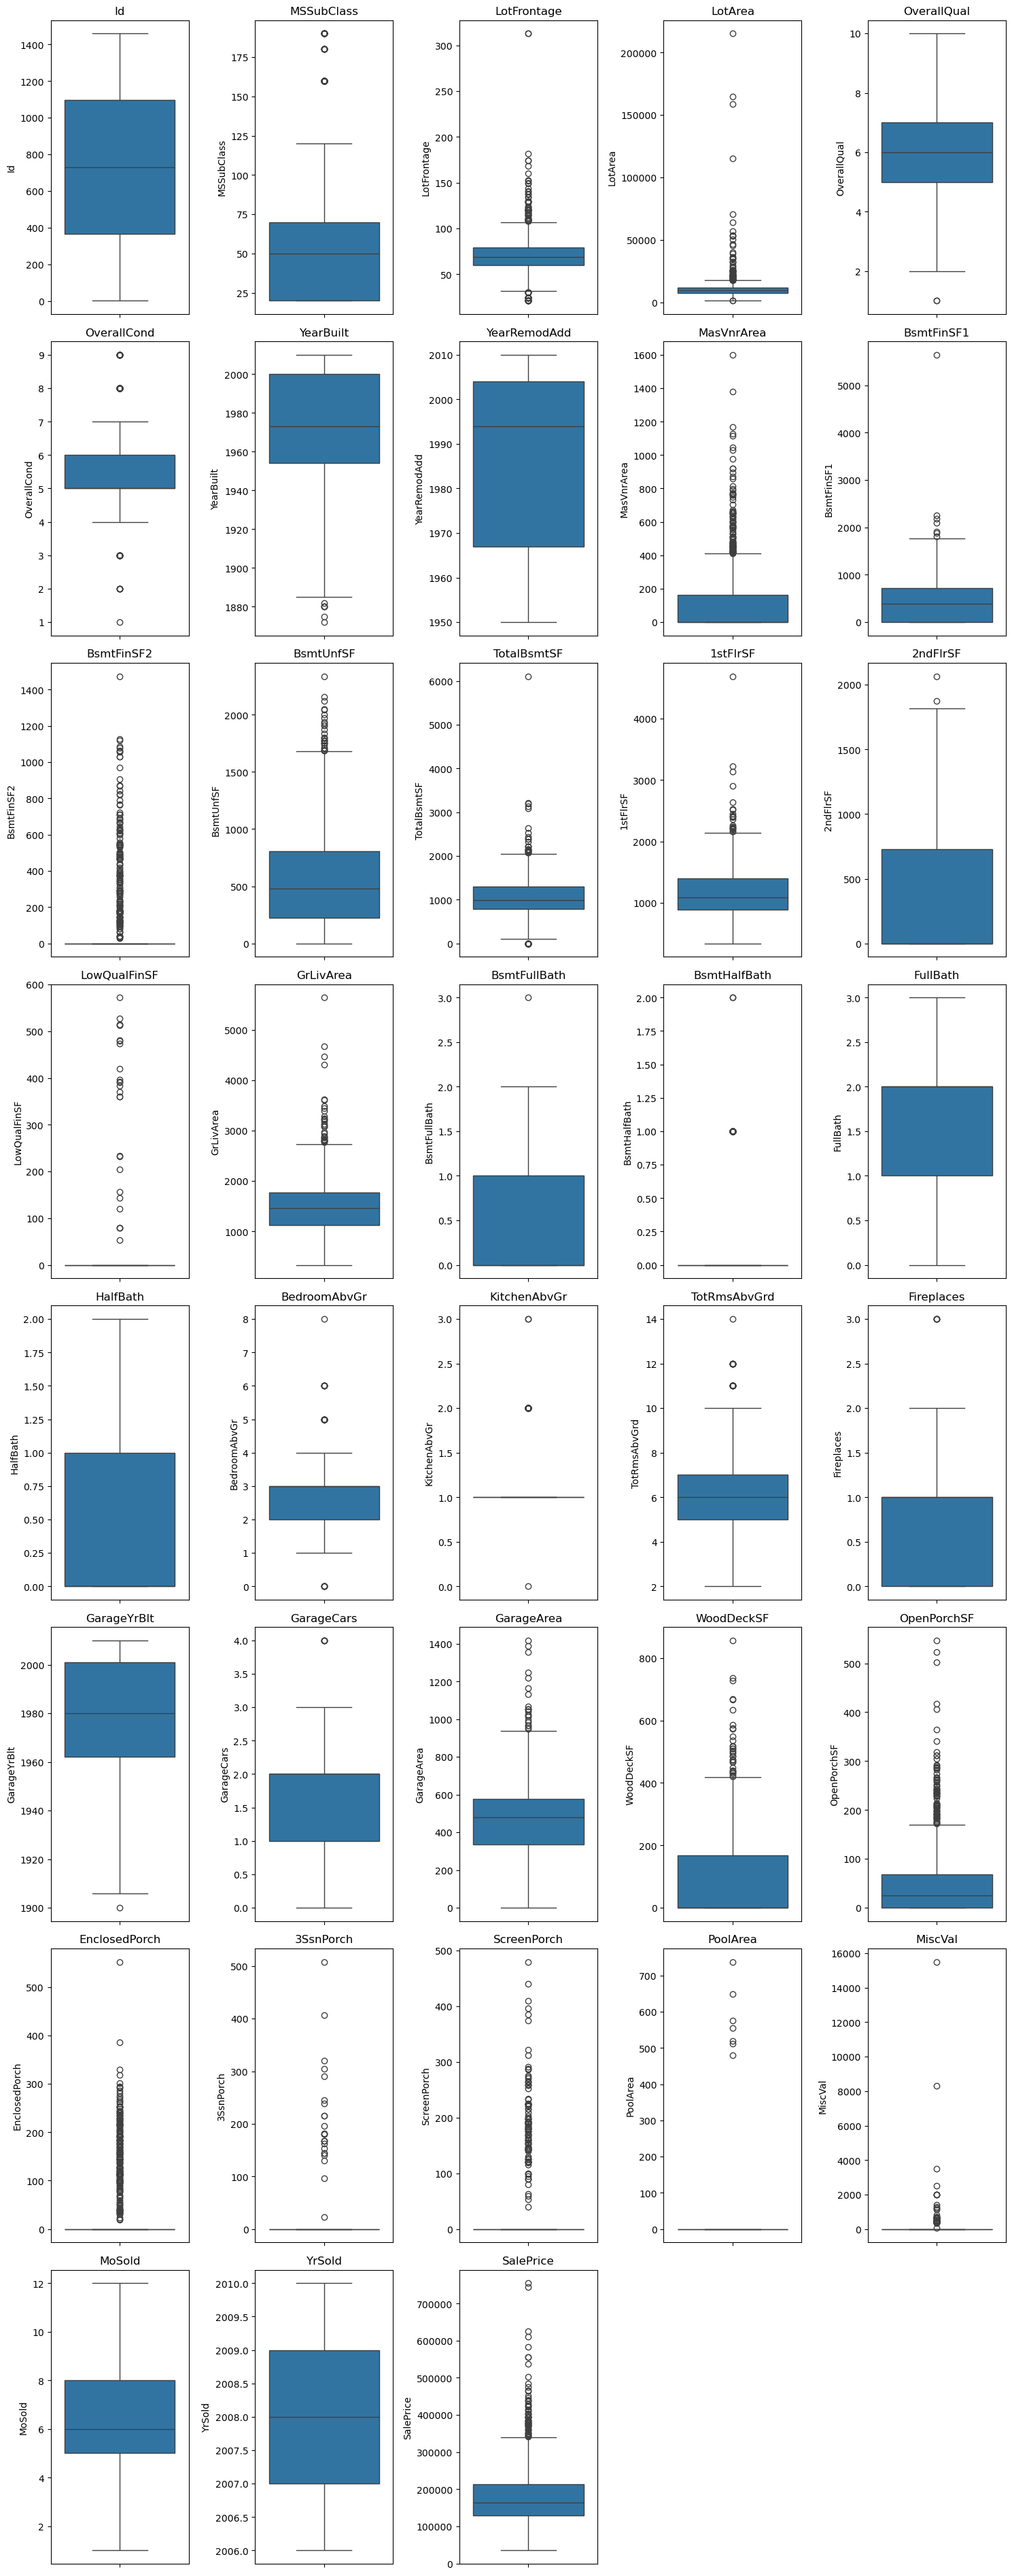

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
def detectar_outliers(df):
    outlier_info = {}
    for col in df.select_dtypes(include=['int64', 'float64']).columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
        outlier_info[col] = len(outliers)
    return pd.DataFrame.from_dict(outlier_info, orient='index', columns=['Cantidad_Outliers']).sort_values(by='Cantidad_Outliers', ascending=False)

tabla_outliers = detectar_outliers(df_limpiado)
print(tabla_outliers)

num_cols = df_limpiado.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(15, 5*len(num_cols)//5))
for i, col in enumerate(num_cols, 1):
    plt.subplot(len(num_cols)//5 + 1, 5, i)
    sns.boxplot(y=df_limpiado[col])
    plt.title(col)
plt.tight_layout()
plt.show()

Los resultados muestran que varias variables del conjunto de datos presentan una cantidad notable de valores atípicos (outliers), especialmente EnclosedPorch, BsmtFinSF2, OverallCond, ScreenPorch y LotFrontage, que superan con claridad el centenar de registros atípicos. La mayoría de estas variables están relacionadas con superficies, características del sótano, del porche o medidas de la parcela, algo habitual en datos inmobiliarios, donde existen viviendas con dimensiones o atributos poco comunes. En este contexto, muchos de estos valores extremos no representan errores, sino la variabilidad natural del mercado inmobiliario.

No obstante, en variables clave para el análisis y la modelización, como SalePrice, GrLivArea, TotalBsmtSF o LotArea, la presencia de valores atípicos (aunque en menor medida) puede tener un impacto significativo en el rendimiento de técnicas sensibles a la escala y a la dispersión de los datos, como el análisis de componentes principales (PCA) o los algoritmos de clustering. Por este motivo, y dado que el objetivo del estudio es analizar y modelizar el precio de las viviendas, se ha optado por tratar los valores atípicos en lugar de ignorarlos, evaluando su impacto sobre los resultados.

En particular, se ha comprobado que el tratamiento de los atípicos mejora la estabilidad de los modelos y la calidad de los resultados obtenidos, por lo que se trabajará con una versión del conjunto de datos sin valores extremos excesivos. Adicionalmente, se aplicará estandarización de las variables numéricas cuando sea necesario, con el fin de reducir la influencia desproporcionada de observaciones extremas y garantizar que todas las variables contribuyan de forma equilibrada al análisis.

Shape original: (1460, 75)
Shape tras tratar outliers: (1460, 75)


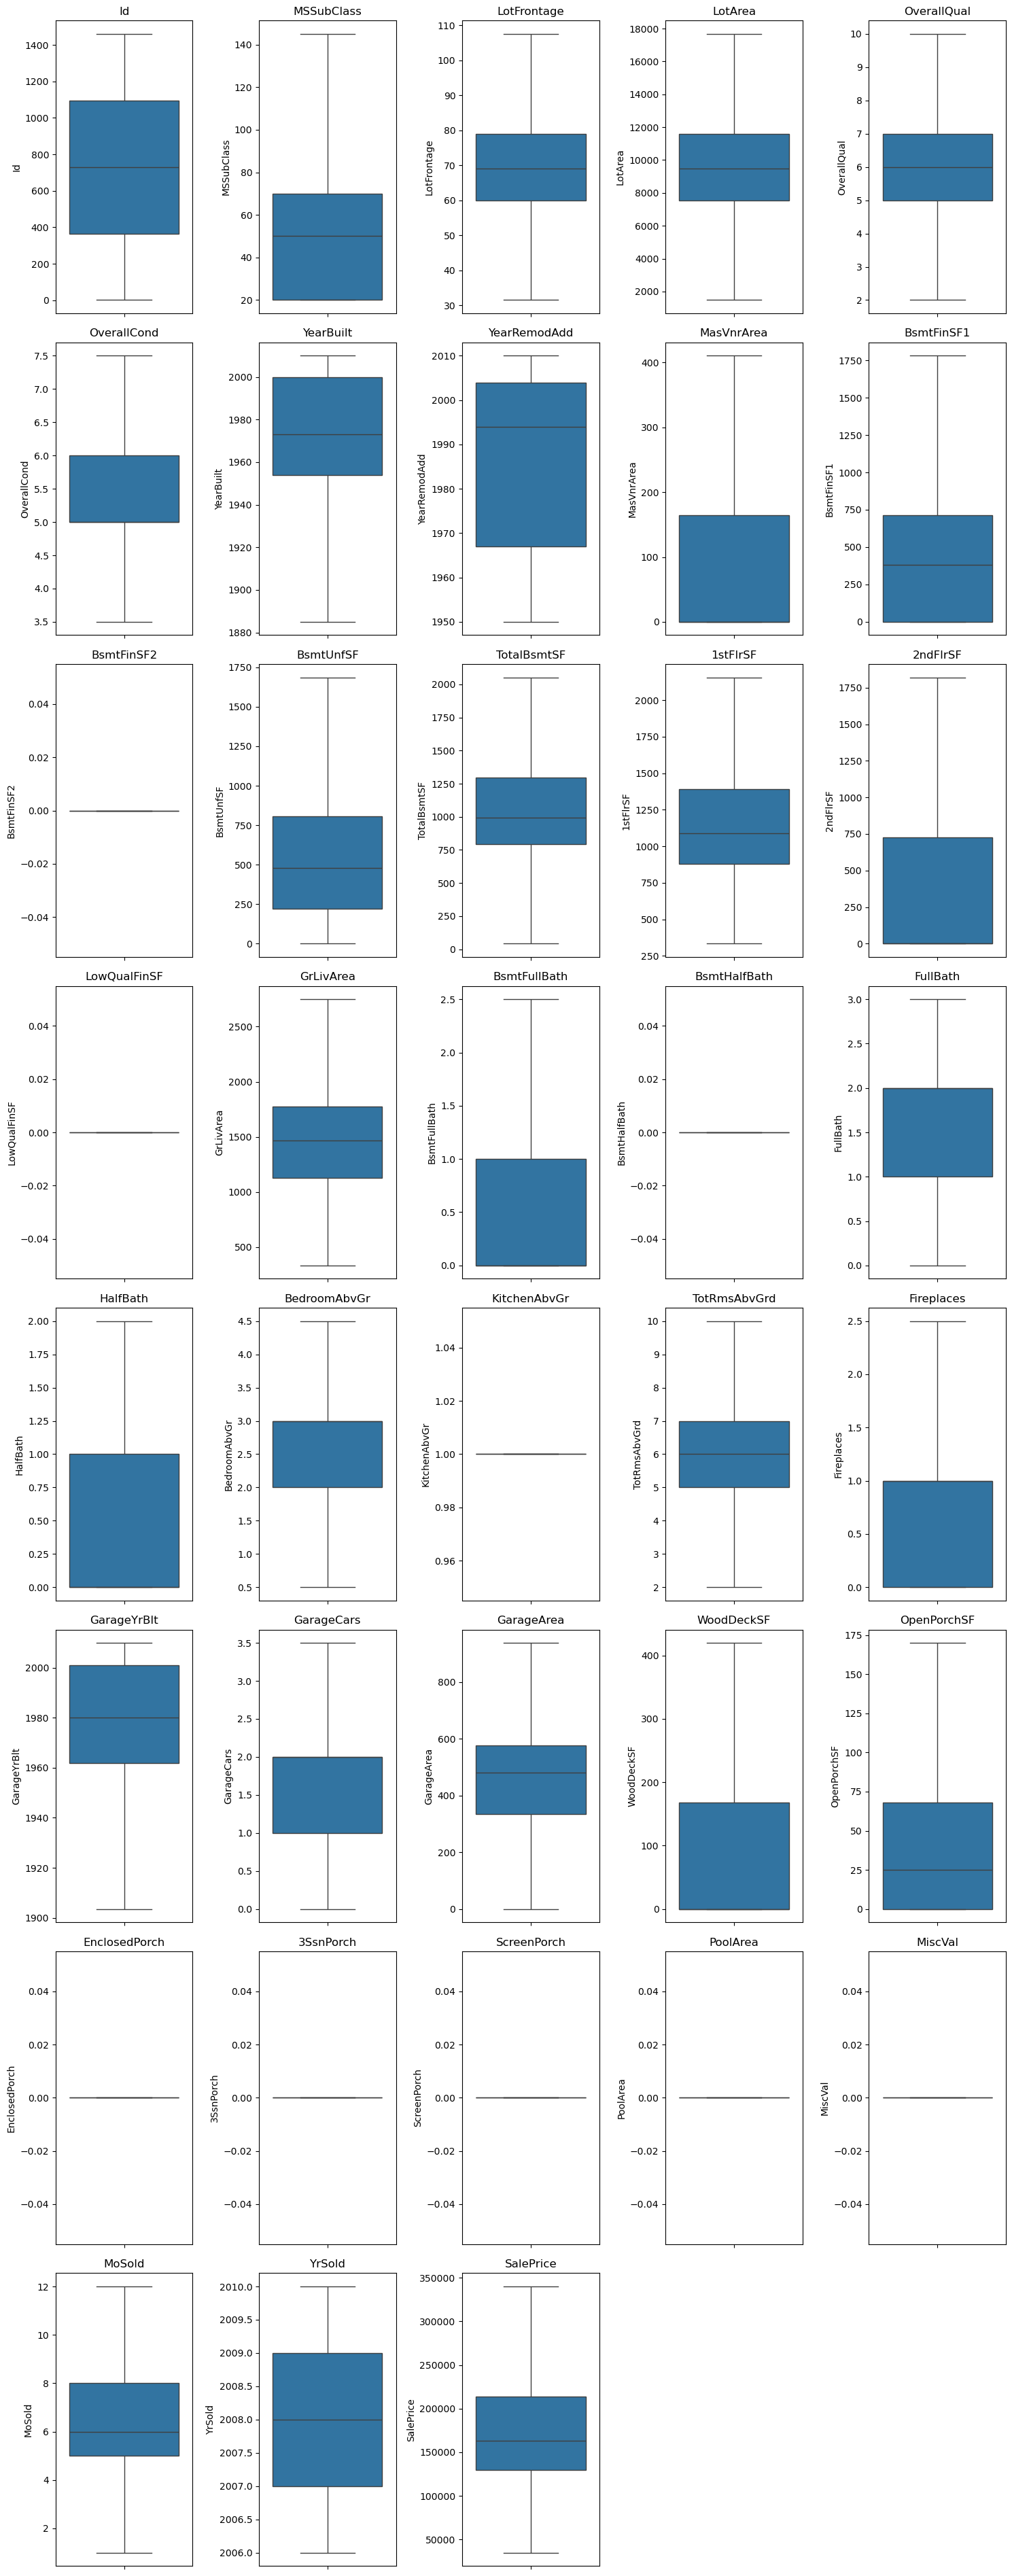

In [6]:
def tratar_outliers_iqr(df):
    df_tratado = df.copy()
    
    for col in df_tratado.select_dtypes(include=['int64', 'float64']).columns:
        Q1 = df_tratado[col].quantile(0.25)
        Q3 = df_tratado[col].quantile(0.75)
        IQR = Q3 - Q1
        limite_inf = Q1 - 1.5 * IQR
        limite_sup = Q3 + 1.5 * IQR
        
        # Winsorización
        df_tratado[col] = df_tratado[col].clip(limite_inf, limite_sup)
    
    return df_tratado
df_tratado_atipicos = tratar_outliers_iqr(df_limpiado)

print("Shape original:", df_limpiado.shape)
print("Shape tras tratar outliers:", df_tratado_atipicos.shape)
num_cols = df_tratado_atipicos.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(15, 5*len(num_cols)//5))
for i, col in enumerate(num_cols, 1):
    plt.subplot(len(num_cols)//5 + 1, 5, i)
    sns.boxplot(y=df_tratado_atipicos[col])
    plt.title(col)

plt.tight_layout()
plt.show()


El código implementa un tratamiento de valores atípicos basado en el método del rango intercuartílico (IQR) aplicado exclusivamente a las variables numéricas del conjunto de datos. Para cada variable, se calculan el primer cuartil (Q1), el tercer cuartil (Q3) y el IQR como la diferencia entre ambos. A partir de estos valores se definen un límite inferior y superior siguiendo el criterio estándar de 1.5·IQR. En lugar de eliminar las observaciones que superan estos límites, se aplica una **winsorización**, recortando los valores extremos al límite correspondiente mediante la función clip. Este proceso se realiza sobre una copia del conjunto de datos original, generando un nuevo dataframe (df_tratado_atipicos) que preserva la estructura original. Finalmente, se visualiza el efecto del tratamiento mediante diagramas de caja para comprobar la reducción de la dispersión extrema en cada variable.

## 2.3 Visualización

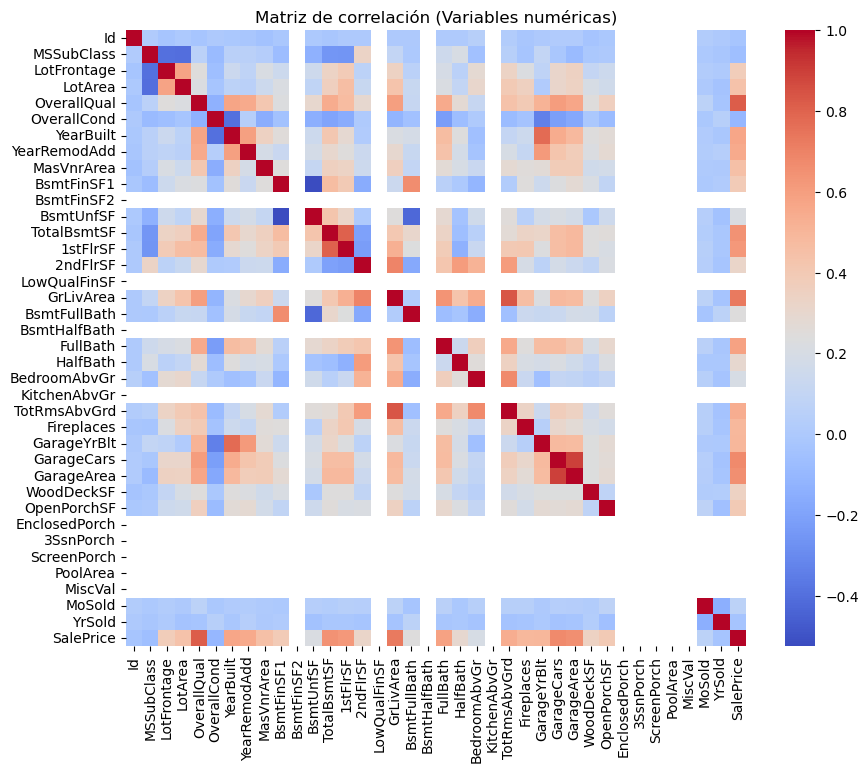

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_num = df_tratado_atipicos.select_dtypes(include=['int64','float64'])

corr_num = df_num.corr(method='pearson');

plt.figure(figsize=(10,8))
sns.heatmap(corr_num, cmap="coolwarm", annot=False)
plt.title("Matriz de correlación (Variables numéricas)")
plt.show()

Las correlaciones muestran cómo cada variable numérica del conjunto de datos se relaciona con SalePrice, que es nuestra variable objetivo. En primer lugar, se observa que variables como OverallQual (0.79), GrLivArea (0.71), GarageCars (0.64), GarageArea (0.62), TotalBsmtSF (0.61), 1stFlrSF (0.60) y YearBuilt (0.52) presentan correlaciones altas y positivas con el precio de venta, lo que indica que son características especialmente informativas para predecirlo. También se aprecia que características de la parcela, como LotFrontage (0.33) y LotArea (0.26), mantienen una relación moderada, aunque menos determinante. Por el contrario, variables como MSSubClass, OverallCond, KitchenAbvGr, EnclosedPorch o MiscVal muestran correlaciones muy bajas o incluso negativas, sugiriendo que aportan poca información predictiva y podrían no ser relevantes para el modelo.

Además, se ve que existen varios bloques de variables fuertemente correlacionadas entre sí, como TotalBsmtSF, 1stFlrSF, GrLivArea y GarageArea, que reflejan que las viviendas más grandes suelen tener también garajes más amplios y sótanos más extensos. Aunque esto es esperable, también implica posible multicolinealidad, algo a considerar si se usan modelos lineales. 

Matriz de correlación categórica (Cramer's V)
               MSZoning    Street  LotShape  LandContour  Utilities  \
MSZoning       1.000000  0.254738  0.160798     0.114652   0.013565   
Street         0.254738  0.916323  0.056532     0.122497   0.000000   
LotShape       0.160798  0.056532  1.000000     0.134292   0.037177   
LandContour    0.114652  0.122497  0.134292     1.000000   0.008826   
Utilities      0.013565  0.000000  0.037177     0.008826   0.499657   
LotConfig      0.082503  0.031050  0.226854     0.079609   0.099801   
LandSlope      0.088819  0.180009  0.127173     0.459180   0.006220   
Neighborhood   0.652480  0.236371  0.275455     0.381687   0.160151   
Condition1     0.102750  0.180734  0.128089     0.068056   0.010430   
Condition2     0.090750  0.006545  0.060790     0.091150   0.002667   
BldgType       0.195389  0.124016  0.099326     0.086507   0.011612   
HouseStyle     0.196826  0.071913  0.100764     0.143461   0.121284   
RoofStyle      0.093425  0.0236

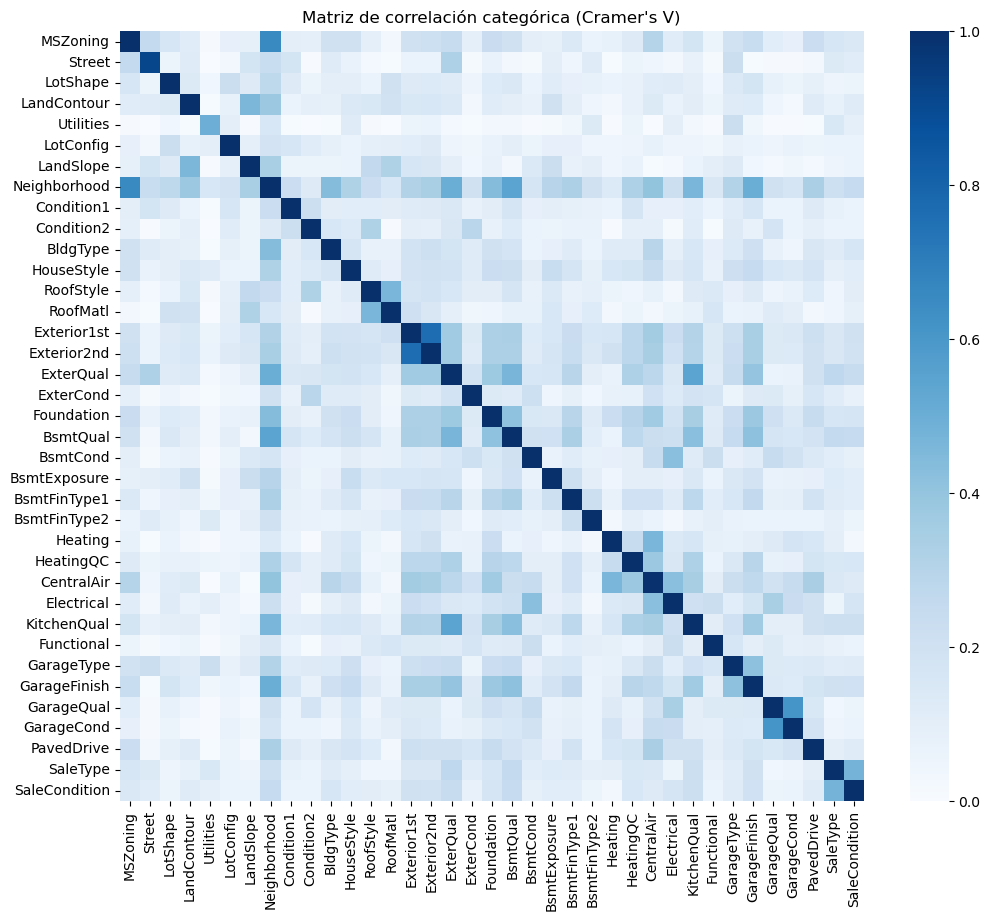

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    tabla = pd.crosstab(x, y)
    chi2 = chi2_contingency(tabla)[0]
    n = tabla.sum().sum()
    r, k = tabla.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

df_cat = df.select_dtypes(include=['object', 'category'])

matriz_cramer = pd.DataFrame(
    np.zeros((len(df_cat.columns), len(df_cat.columns))),
    index=df_cat.columns, 
    columns=df_cat.columns
)

for col1 in df_cat.columns:
    for col2 in df_cat.columns:
        matriz_cramer.loc[col1, col2] = cramers_v(df_cat[col1], df_cat[col2])

print("Matriz de correlación categórica (Cramer's V)")
print(matriz_cramer)

plt.figure(figsize=(12,10))
sns.heatmap(matriz_cramer, cmap="Blues", annot=False)
plt.title("Matriz de correlación categórica (Cramer's V)")
plt.show()


Las variables numéricas y categóricas requieren métodos distintos porque representan información diferente y no pueden analizarse con la misma métrica. En las variables numéricas se puede medir correlación mediante Pearson, ya que se basan en magnitudes continuas donde existe una relación lineal evaluable matemáticamente. En cambio, las variables categóricas no tienen valores numéricos comparables ni orden natural (por ejemplo, tipos de techo, zonas, materiales), por lo que Pearson no tiene sentido en ese contexto. Para ellas se emplea una medida basada en tablas de contingencia, como Cramer’s V, que captura la asociación entre categorías sin necesidad de valores numéricos. Por eso es necesario disponer de dos códigos diferentes, cada uno adaptado al tipo de variable que se analiza y a la naturaleza de la información que contienen.

La matriz de correlación categórica mediante Cramer’s V muestra el grado de asociación entre las variables cualitativas del dataset. En general, los valores tienden a ser bajos, lo cual es habitual en variables categóricas de viviendas, ya que la mayoría representan características independientes entre sí (tipos de vivienda, materiales, zonas, calidades, etc.). Sin embargo, es posible observar algunas asociaciones más marcadas entre variables relacionadas estructuralmente, como aquellas que describen categorías de construcciones, características del vecindario o tipologías del inmueble. Valores más elevados indican que dos categorías tienden a aparecer juntas con mayor frecuencia de la esperada al azar, mientras que valores cercanos a cero indican independencia. 

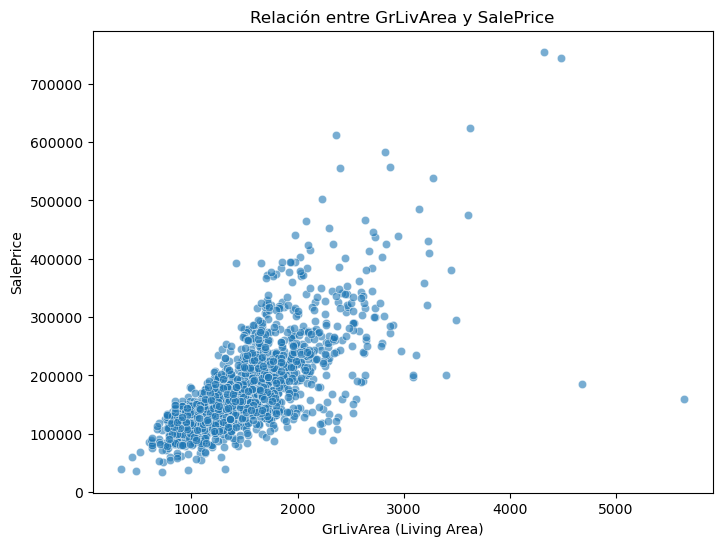

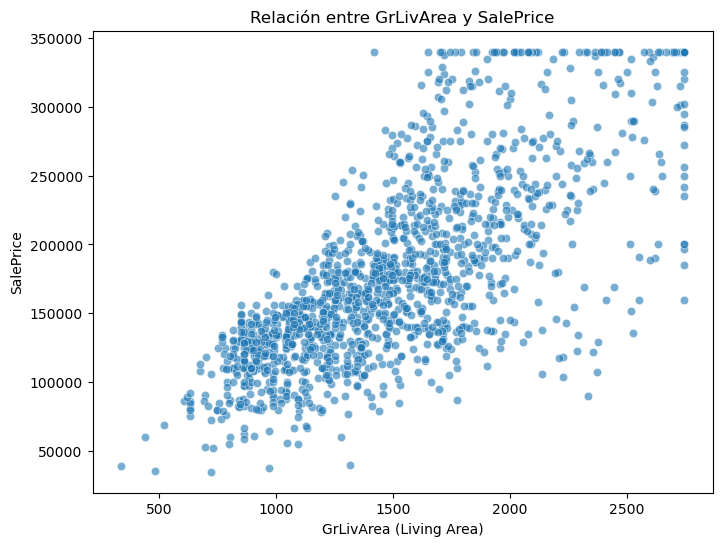

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="GrLivArea", y="SalePrice", alpha=0.6)
plt.title("Relación entre GrLivArea y SalePrice")
plt.xlabel("GrLivArea (Living Area)")
plt.ylabel("SalePrice")
plt.show()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_tratado_atipicos, x="GrLivArea", y="SalePrice", alpha=0.6)
plt.title("Relación entre GrLivArea y SalePrice")
plt.xlabel("GrLivArea (Living Area)")
plt.ylabel("SalePrice")
plt.show()

El código genera dos gráficos de dispersión idénticos en formato pero utilizando conjuntos de datos diferentes. Ambos visualizan la relación entre la variable GrLivArea (área habitable sobre nivel) y SalePrice (precio de venta) mediante un scatter plot con puntos semitransparentes (alpha=0.6) para mejorar la legibilidad en zonas de alta densidad. La primera gráfica se crea con el dataframe df, mientras que la segunda usa df_tratado_atipicos, permitiendo comparar cómo cambia la relación tras eliminar o ajustar los valores atípicos. Cada gráfico incluye títulos y etiquetas de ejes claras para facilitar la interpretación.

En la gráfica con datos df se observa una tendencia positiva clara: a mayor área habitable, mayor precio. Sin embargo, aparecen varios puntos atípicos notables, especialmente dos viviendas con áreas superiores a 4000 pies cuadrados pero precios inusualmente bajos (por debajo de $200,000), que distorsionan la relación general. En contraste, la gráfica con datos tratados (df_tratado_atipicos) muestra una correlación mucho más definida y compacta (tener en cuenta que la escala de los ejes), donde la nube de puntos se alinea casi linealmente sin las distorsiones extremas. Esto confirma que los atípicos estaban afectando significativamente la percepción de la relación entre área y precio, y que su tratamiento permite identificar un patrón más realista y útil para modelado predictivo.


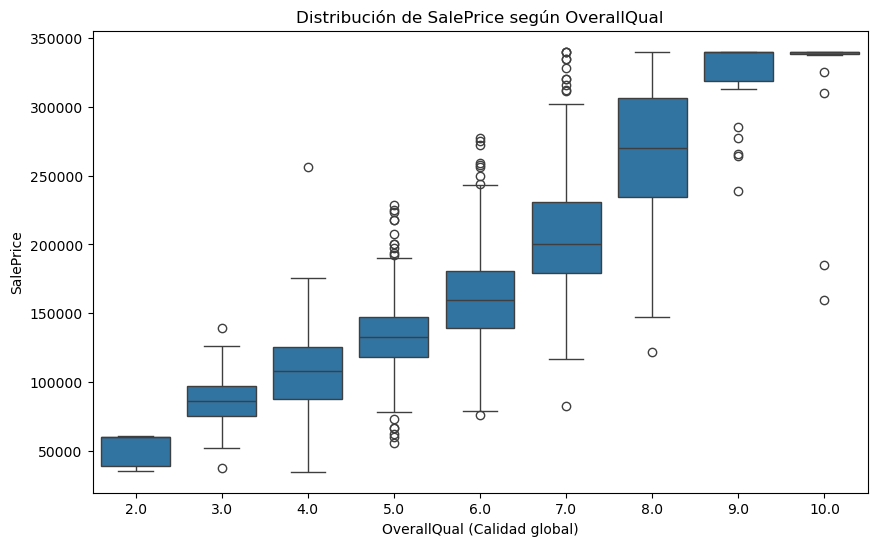

In [10]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df_tratado_atipicos, x="OverallQual", y="SalePrice")
plt.title("Distribución de SalePrice según OverallQual")
plt.xlabel("OverallQual (Calidad global)")
plt.ylabel("SalePrice")
plt.show()


El gráfico de OverallQual y SalePrice confirma una relación lineal fuerte y consistente: a mayor calidad general de la vivienda, mayor precio. Cada nivel de calidad (escala 1-10) se corresponde con una banda de precios claramente diferenciada, con incrementos particularmente pronunciados a partir de la calificación 7. La ausencia de valores atípicos extremos y la distribución ordenada de los puntos demuestran la efectividad del tratamiento previo de datos y refuerzan que OverallQual es una variable fundamental y altamente predictiva para la valoración inmobiliaria.

# 3.  Técnicas de reducción de la dimensión

## 3. 1 PCA sin tratar los atípicos

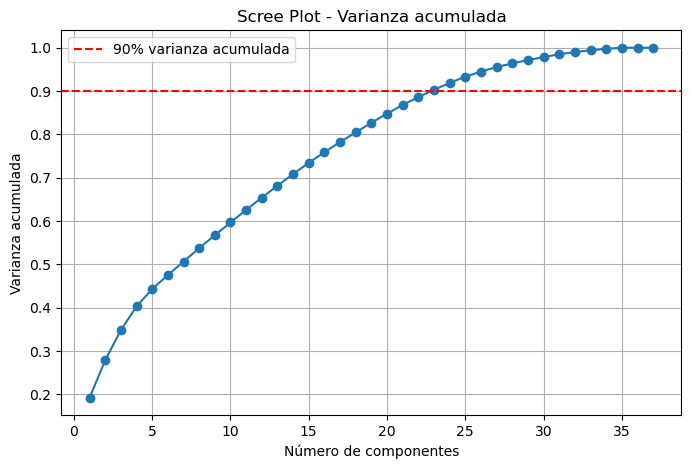

Resumen PCA
   Componente  Varianza_explicada  Varianza_acumulada
0         PC1        1.925335e-01            0.192533
1         PC2        8.659390e-02            0.279127
2         PC3        6.952302e-02            0.348650
3         PC4        5.467028e-02            0.403321
4         PC5        3.996692e-02            0.443288
5         PC6        3.227544e-02            0.475563
6         PC7        3.123310e-02            0.506796
7         PC8        3.072147e-02            0.537518
8         PC9        2.996009e-02            0.567478
9        PC10        2.940441e-02            0.596882
10       PC11        2.899662e-02            0.625879
11       PC12        2.826579e-02            0.654145
12       PC13        2.744394e-02            0.681588
13       PC14        2.703158e-02            0.708620
14       PC15        2.579919e-02            0.734419
15       PC16        2.449448e-02            0.758914
16       PC17        2.354328e-02            0.782457
17       PC18   

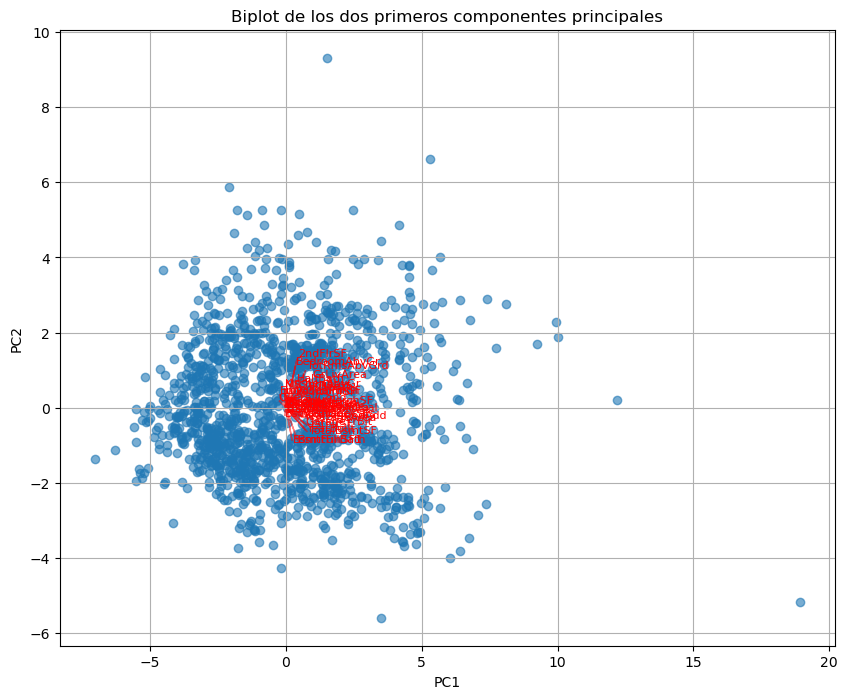

In [11]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

df_num = df_limpiado.select_dtypes(include=['int64','float64']).copy()
X = df_num.drop(columns=['SalePrice'], errors='ignore') 

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_
cum_var = explained_var.cumsum()

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o', linestyle='-')
plt.axhline(y=0.9, color='r', linestyle='--', label='90% varianza acumulada')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza acumulada')
plt.title('Scree Plot - Varianza acumulada')
plt.grid(True)
plt.legend()
plt.show()

pca_summary = pd.DataFrame({
    'Componente': [f'PC{i+1}' for i in range(len(explained_var))],
    'Varianza_explicada': explained_var,
    'Varianza_acumulada': cum_var
})

print("Resumen PCA")
print(pca_summary)
plt.figure(figsize=(10,8))
pc1 = X_pca[:, 0]
pc2 = X_pca[:, 1]

plt.scatter(pc1, pc2, alpha=0.6)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Biplot de los dos primeros componentes principales')

for i, col in enumerate(X.columns):
    plt.arrow(0, 0, 
              pca.components_[0, i]*3,
              pca.components_[1, i]*3, 
              color='r', alpha=0.5)
    plt.text(pca.components_[0, i]*3.2, pca.components_[1, i]*3.2, col, color='r', fontsize=8)

plt.grid(True)
plt.show()


El código implementa un análisis de componentes principales (PCA) sobre las variables numéricas de nuestro dataset, excluyendo la variable objetivo SalePrice. Primero, se seleccionan las columnas numéricas y se estandarizan usando StandardScaler, lo cual es importante para que todas las variables tengan media 0 y desviación estándar 1, evitando que las variables con mayor magnitud dominen el PCA. Luego, se aplica PCA y se calcula tanto la varianza explicada de cada componente como la varianza acumulada, que permite ver qué proporción de la información total captura cada componente y el conjunto de componentes. A continuación, se genera un Scree Plot, en el que se visualiza la varianza acumulada y se marca con una línea discontinua el 90%, para ayudar a decidir cuántos componentes retener. Además, se crea un biplot con los dos primeros componentes principales, mostrando las observaciones proyectadas y las flechas que representan la contribución de cada variable original a estos componentes. Finalmente, se construye un DataFrame resumen que organiza la varianza explicada y acumulada de manera clara para su interpretación.

Los resultados del PCA muestran que la varianza de los datos está muy distribuida entre muchos componentes: el primer componente explica aproximadamente el 19,25% de la varianza total, el segundo 8,66%, el tercero 6,95%, y así sucesivamente. Esto indica que ningún componente por sí solo captura la mayor parte de la información, y que para retener gran parte de la varianza se requieren muchos componentes. Aplicando las reglas habituales de decisión:

- Varianza acumulada: para capturar el 90% de la varianza, se necesitarían los primeros 23 componentes; para el 80%, los primeros 18 componentes.

- Regla del codo (Scree Plot): el “codo” se observa alrededor de los primeros 4–5 componentes, donde la pendiente de la curva empieza a aplanarse, lo que sugiere que los primeros componentes resumen los patrones principales pero no toda la información.

- Regla de Kaiser (autovalores >1): es menos directa aquí debido a la estandarización, pero indicaría mantener componentes que superen la varianza promedio de las variables originales.

En conclusión, para visualización o análisis exploratorio, bastarían los 4–5 primeros componentes para observar patrones generales. Para modelado predictivo y preservar la mayor parte de la información, conviene quedarse con 23 componentes, que representan el 90% de la varianza acumulada. Esto muestra que, aunque PCA ayuda a reducir algo de ruido y multicolinealidad, en este dataset la reducción de dimensionalidad no es drástica debido a que la información está dispersa entre muchas variables.

## 3.2 PCA tratando los atípicos 

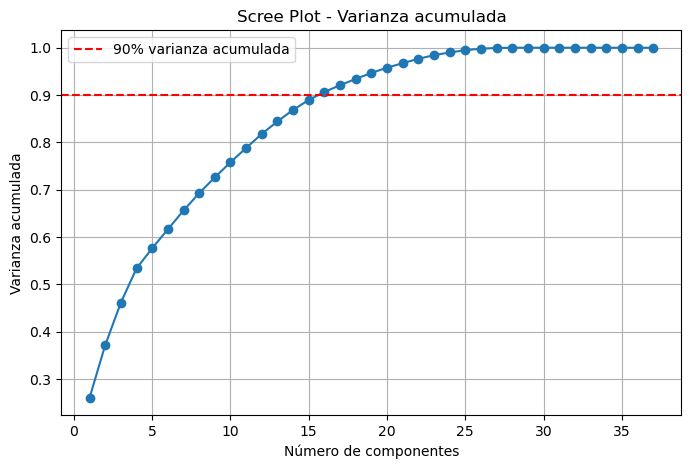

Resumen PCA
   Componente  Varianza_explicada  Varianza_acumulada
0         PC1        2.602059e-01            0.260206
1         PC2        1.113278e-01            0.371534
2         PC3        8.986339e-02            0.461397
3         PC4        7.226345e-02            0.533661
4         PC5        4.246042e-02            0.576121
5         PC6        4.011339e-02            0.616234
6         PC7        3.972249e-02            0.655957
7         PC8        3.664846e-02            0.692605
8         PC9        3.336647e-02            0.725972
9        PC10        3.194271e-02            0.757914
10       PC11        3.020001e-02            0.788115
11       PC12        2.978702e-02            0.817902
12       PC13        2.630438e-02            0.844206
13       PC14        2.438195e-02            0.868588
14       PC15        2.095572e-02            0.889544
15       PC16        1.702431e-02            0.906568
16       PC17        1.422964e-02            0.920798
17       PC18   

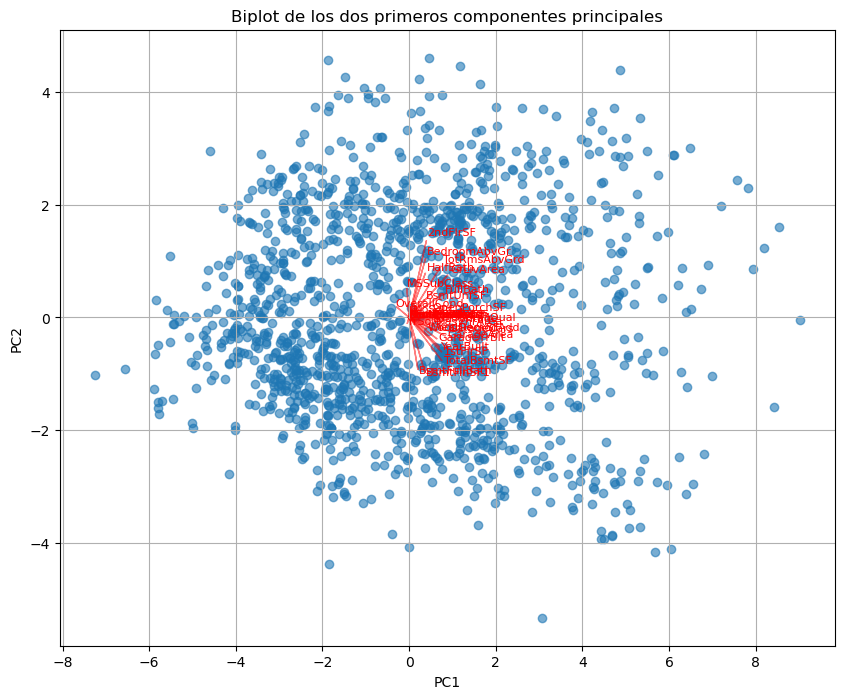

In [12]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

df_num = df_tratado_atipicos.select_dtypes(include=['int64','float64']).copy()
X = df_num.drop(columns=['SalePrice'], errors='ignore') 

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_
cum_var = explained_var.cumsum()

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o', linestyle='-')
plt.axhline(y=0.9, color='r', linestyle='--', label='90% varianza acumulada')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza acumulada')
plt.title('Scree Plot - Varianza acumulada')
plt.grid(True)
plt.legend()
plt.show()

pca_summary = pd.DataFrame({
    'Componente': [f'PC{i+1}' for i in range(len(explained_var))],
    'Varianza_explicada': explained_var,
    'Varianza_acumulada': cum_var
})

print("Resumen PCA")
print(pca_summary)
plt.figure(figsize=(10,8))
pc1 = X_pca[:, 0]
pc2 = X_pca[:, 1]

plt.scatter(pc1, pc2, alpha=0.6)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Biplot de los dos primeros componentes principales')

for i, col in enumerate(X.columns):
    plt.arrow(0, 0, 
              pca.components_[0, i]*3,
              pca.components_[1, i]*3, 
              color='r', alpha=0.5)
    plt.text(pca.components_[0, i]*3.2, pca.components_[1, i]*3.2, col, color='r', fontsize=8)

plt.grid(True)
plt.show()


El código está utilizando el conjunto de datos df_tratado_atipicos, lo que indica explícitamente que los valores atípicos ya han sido procesados previamente. Esto significa que antes de ejecutar este análisis PCA, se aplicaron técnicas de detección y tratamiento de outliers (como eliminación, transformación o imputación) para reducir su influencia. El uso de StandardScaler() después de este tratamiento asegura que los datos estandarizados no estén distorsionados por valores extremos, lo que permite que el PCA capture la estructura subyacente de la mayoría de los datos en lugar de estar sesgado por observaciones anómalas. Este enfoque mejora la robustez y representatividad de los componentes principales obtenidos.

El PCA realizado sobre los datos tratados muestra que se necesitan 16 o 17 componentes principales para alcanzar aproximadamente el 90% de la varianza acumulada, lo que indica una alta dimensionalidad intrínseca en los datos. El primer componente (PC1) explica el 26.02% de la varianza, seguido por PC2 con 11.13%, sugiriendo que aunque PC1 captura la mayor parte de la información, existe una dispersión significativa de la varianza entre múltiples componentes. El gráfico de varianza acumulada (scree plot) muestra una curva que se estabiliza gradualmente después de los primeros componentes, sin un "codo" pronunciado, lo que respalda la necesidad de retener varios componentes para representar adecuadamente los datos.

En el biplot la distribución de puntos muestra una dispersión relativamente homogénea sin agrupamientos extremos, confirmando la efectividad del tratamiento de atípicos. Las flechas de las variables revelan correlaciones: variables con flechas largas y en direcciones similares (como OverallQual y GrLivArea) contribuyen fuertemente a los componentes y están altamente correlacionadas entre sí. La orientación de las flechas respecto a los ejes indica qué variables dominan cada componente: las que apuntan hacia la derecha/influencian principalmente PC1 (atributos estructurales y de calidad), mientras que las que apuntan hacia arriba/influyen en PC2 podrían representar características complementarias o de acabados. Esta visualización ayuda a identificar patrones y relaciones entre variables que explican las diferencias clave entre las viviendas en el espacio reducido.

# 4. Clustering

Dado el tipo de datos con los que estamos trabajando (dataset complejo, con muchas variables numéricas, correlaciones moderadas y sin estructuras muy marcadas en PCA), es importante analizar cuidadosamente qué método de clustering puede capturar mejor la estructura.  
A continuación, se comparan las tres opciones:

1. **K-Means**  
   Este algoritmo asume que los clusters son esféricos, de tamaños similares y bien separados. Requiere predefinir el número de clusters y su desempeño empeora cuando hay outliers o formas de cluster no circulares.  
   En nuestro caso, el PCA indica que no hay una estructura muy clara ni componentes dominantes, lo que sugiere que los datos no presentan clusters simples ni muy bien definidos. Además, existen bastantes valores atípicos, lo que puede afectar negativamente a K-Means. Aun así, puede ser útil como línea base porque funciona bien en datasets grandes y continuos.

2. **Clustering jerárquico**  
   Es una técnica más flexible y no requiere especificar de antemano el número de clusters. Permite visualizar cómo se agrupan los datos mediante un dendrograma.  
   Sin embargo, tiene dos inconvenientes importantes:  
   - Es computacionalmente costoso con muchos datos.  
   - No funciona bien cuando hay ruido o muchos outliers.  
   Considerando que nuestro dataset es amplio y presenta valores fuera de lo común, el clustering jerárquico puede generar fusiones poco representativas y dendrogramas difíciles de interpretar.

3. **DBSCAN**  
   Este algoritmo es robusto frente a outliers y detecta clusters de forma arbitraria, no necesariamente esférica. No requiere especificar el número de clusters y puede identificar puntos de ruido.  
   Su principal dificultad es seleccionar los parámetros correctos (eps y min_samples), y en datasets de alta dimensionalidad puede volverse poco estable porque las distancias dejan de ser informativas.  
   Dado que nuestro PCA muestra que se necesitan más de 20 componentes para explicar el 90% de la varianza, el espacio sigue siendo relativamente de alta dimensión, lo que puede afectar el rendimiento de DBSCAN.

**Conclusión**  
Dado el comportamiento de nuestros datos y el objetivo del estudio, la opción más razonable sería comenzar con **K-Means** como método base por su estabilidad y su capacidad para manejar datasets grandes con muchas variables, siempre después de haber reducido dimensionalidad mediante PCA. A continuación, sería recomendable aplicar **DBSCAN** sobre las primeras componentes principales (por ejemplo, PC1–PC5), donde la estructura es más clara y la dimensionalidad más baja, ya que esto permite aprovechar su capacidad para detectar outliers y formas arbitrarias de cluster.  
El clustering jerárquico es menos adecuado debido al tamaño del dataset y la presencia de ruido.  


## 4.1 K-Medias

### 4.1.1 Sin tratar los atípicos 

Componentes retenidos por PCA: 23


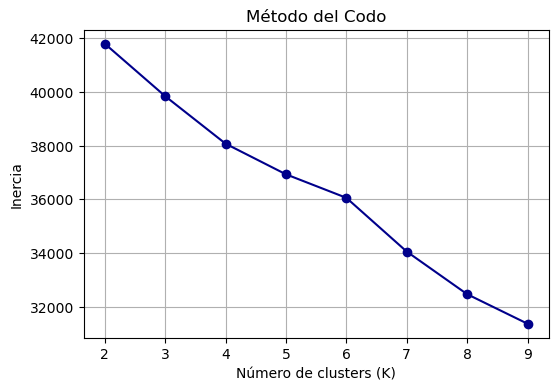

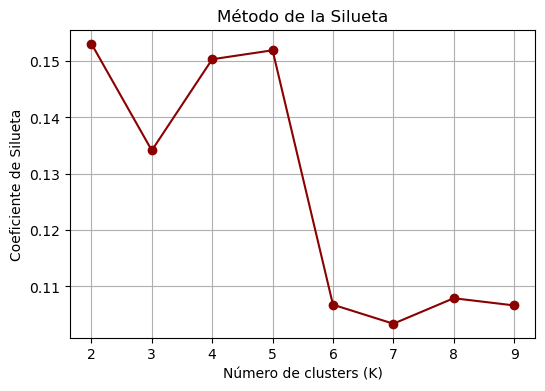

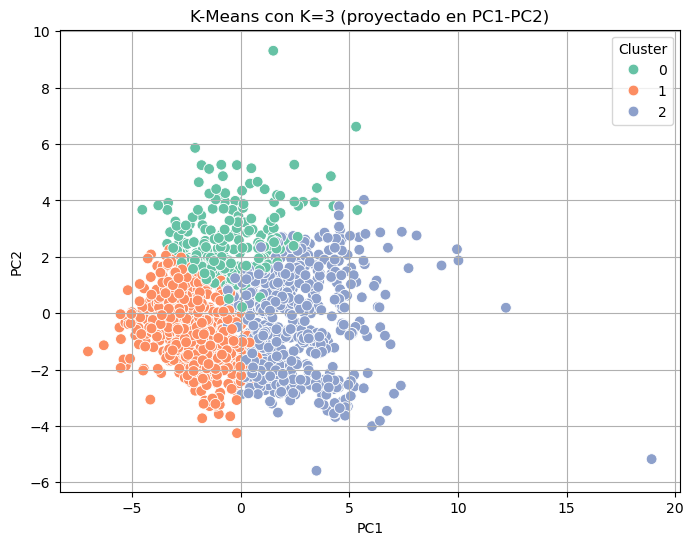

C:\Users\miria\AppData\Local\Temp\ipykernel_6620\3958290056.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_limpiado, x="Cluster", y="SalePrice", palette="Set3")


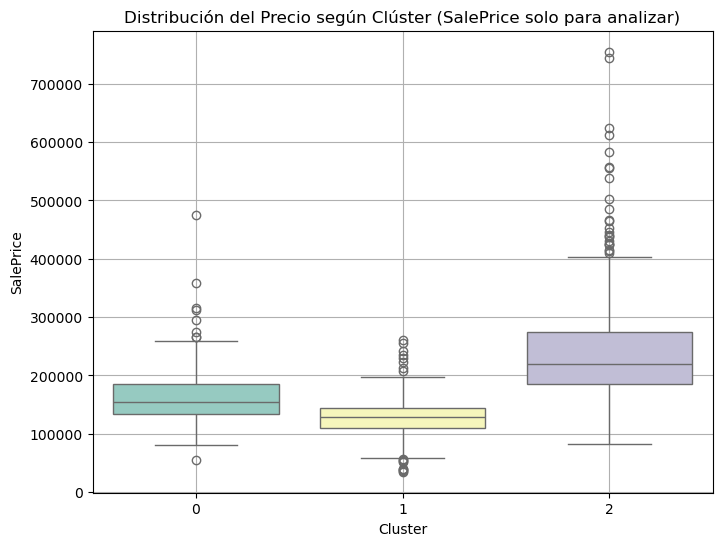

In [13]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

df_num = df_limpiado.select_dtypes(include=['int64', 'float64']).copy()
X = df_num.drop(columns=['SalePrice'], errors='ignore')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=0.90)
X_pca = pca.fit_transform(X_scaled)

print(f"Componentes retenidos por PCA: {X_pca.shape[1]}")

inertias = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_pca)
    inertias.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertias, marker='o', color='darkblue')
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inercia")
plt.title("Método del Codo")
plt.grid(True)
plt.show()

silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    sil_score = silhouette_score(X_pca, labels)
    silhouette_scores.append(sil_score)

plt.figure(figsize=(6,4))
plt.plot(K_range, silhouette_scores, marker='o', color='darkred')
plt.xlabel("Número de clusters (K)")
plt.ylabel("Coeficiente de Silueta")
plt.title("Método de la Silueta")
plt.grid(True)
plt.show()

k_optimo = 3  

kmeans = KMeans(n_clusters=k_optimo, random_state=42)
clusters = kmeans.fit_predict(X_pca)

df_limpiado['Cluster'] = clusters

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_pca[:, 0], 
    y=X_pca[:, 1], 
    hue=clusters, 
    palette="Set2", 
    s=60
)
plt.title(f"K-Means con K={k_optimo} (proyectado en PC1-PC2)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,6))
sns.boxplot(data=df_limpiado, x="Cluster", y="SalePrice", palette="Set3")
plt.title("Distribución del Precio según Clúster (SalePrice solo para analizar)")
plt.xlabel("Cluster")
plt.ylabel("SalePrice")
plt.grid(True)
plt.show()


Este código realiza un análisis de agrupamiento (clustering) no supervisado utilizando el algoritmo K-Means. Primero, selecciona y estandariza las variables numéricas, excluyendo la variable objetivo (SalePrice). Luego aplica PCA para reducir la dimensionalidad conservando el 90% de la varianza, con el fin de optimizar el rendimiento del clustering. Se utilizan dos métodos para determinar el número óptimo de clústeres (K): el método del codo (inercia) y el coeficiente de silueta, generando gráficas para cada uno. Finalmente, se ejecuta K-Means con el K seleccionado, se visualizan los clústeres en el espacio de las dos primeras componentes principales y se analiza la distribución del precio de venta (SalePrice) entre los clústeres obtenidos, aunque esta variable no fue usada en la creación de los grupos.

Los resultados obtenidos, representados en las gráficas, muestran que según el método del codo, la inercia disminuye notablemente hasta K=3 o K=4, a partir de donde la reducción es menos pronunciada, sugiriendo un posible "codo" en esos valores. Por otro lado, el coeficiente de silueta alcanza su máximo en K=3, indicando una mejor estructura de agrupamiento con tres clústeres. Por lo tanto, se seleccionó K=3 como valor óptimo. La proyección en PCA muestra una separación visual clara entre los tres grupos, y el boxplot posterior revela diferencias en la distribución del precio de venta entre clústeres, lo que valida la utilidad del agrupamiento para segmentar observaciones con características distintas.

### 4.1.2 Tratando los atípicos

Componentes retenidos (sin atípicos): 16


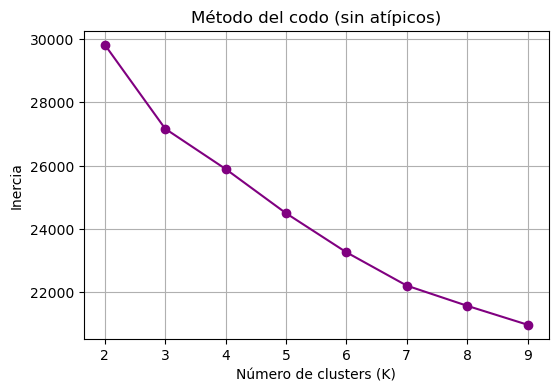

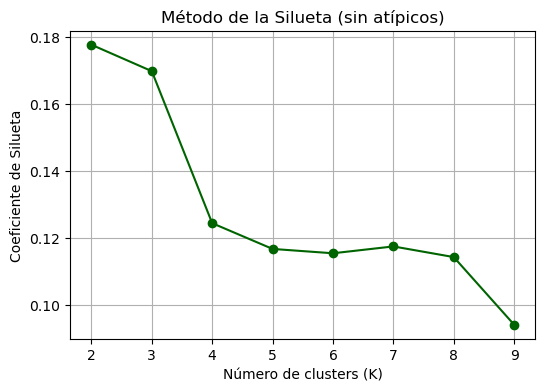

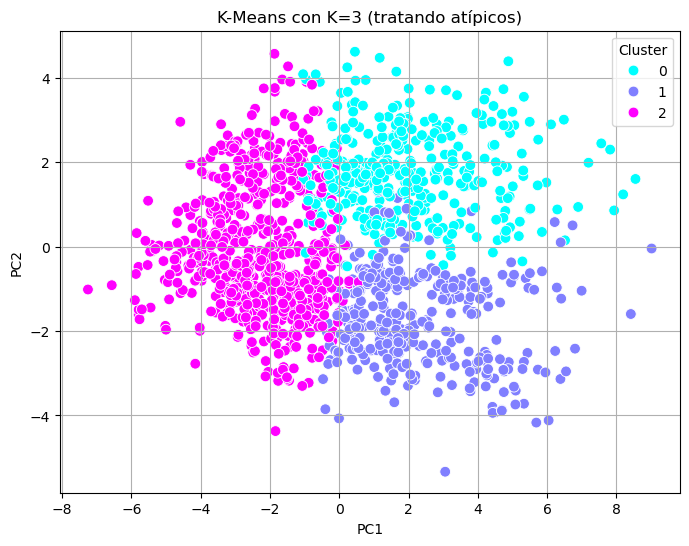

C:\Users\miria\AppData\Local\Temp\ipykernel_6620\2958355988.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_tratado_atipicos, x="Cluster", y="SalePrice", palette="Pastel1")


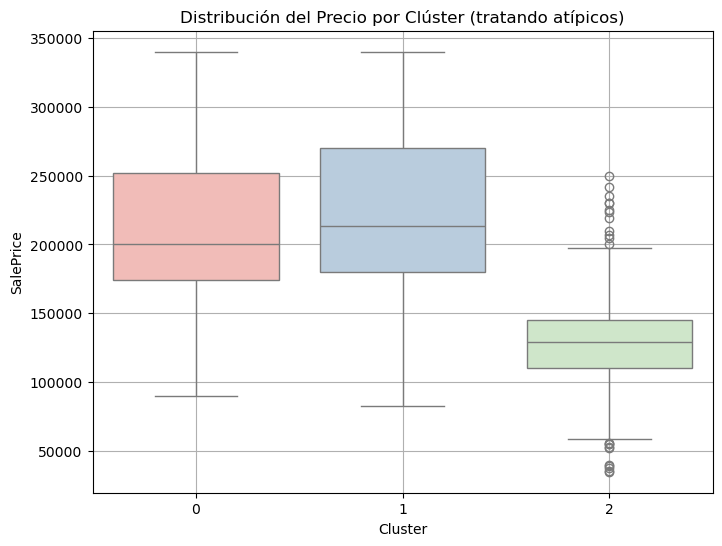

In [14]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

df_num2 = df_tratado_atipicos.select_dtypes(include=['int64','float64'])
X = df_num2.drop(columns=['SalePrice'], errors='ignore')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=0.90)
X_pca = pca.fit_transform(X_scaled)

print(f"Componentes retenidos (sin atípicos): {X_pca.shape[1]}")

K_range = range(2, 10)
inertias = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_pca)
    inertias.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertias, marker='o', color='purple')
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inercia")
plt.title("Método del codo (sin atípicos)")
plt.grid(True)
plt.show()

silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    sil_score = silhouette_score(X_pca, labels)
    silhouette_scores.append(sil_score)

plt.figure(figsize=(6,4))
plt.plot(K_range, silhouette_scores, marker='o', color='darkgreen')
plt.xlabel("Número de clusters (K)")
plt.ylabel("Coeficiente de Silueta")
plt.title("Método de la Silueta (sin atípicos)")
plt.grid(True)
plt.show()

k_optimo = 3
kmeans = KMeans(n_clusters=k_optimo, random_state=42)
clusters = kmeans.fit_predict(X_pca)
df_tratado_atipicos['Cluster'] = clusters

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=clusters,
    palette="cool", 
    s=60
)
plt.title(f"K-Means con K={k_optimo} (tratando atípicos)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,6))
sns.boxplot(data=df_tratado_atipicos, x="Cluster", y="SalePrice", palette="Pastel1")
plt.title("Distribución del Precio por Clúster (tratando atípicos)")
plt.xlabel("Cluster")
plt.ylabel("SalePrice")
plt.grid(True)
plt.show()


La principal diferencia en este segundo código es que utiliza un conjunto de datos previamente tratado para manejar valores atípicos (df_tratado_atipicos) en lugar del conjunto original (df_limpiado). Esto mejora la robustez del análisis al reducir la influencia de observaciones extremas. Además, se mantienen los mismos pasos metodológicos (selección de variables numéricas, estandarización, PCA al 90%, evaluación de K óptimo con codo y silueta, clustering con K=3 y visualización), pero con colores distintos en las gráficas (purple y darkgreen para los métodos, cool y Pastel1 para las visualizaciones) para facilitar la comparación visual con el análisis anterior.

Los resultados obtenidos tras tratar los atípicos muestran un comportamiento más definido y estable en ambos métodos de selección de K. El gráfico del codo presenta una curva más suave con una disminución progresiva de la inercia, manteniendo un posible punto de inflexión en K=3, lo que sugiere que la estructura de los datos es más homogénea y menos distorsionada por valores extremos. Simultáneamente, el coeficiente de silueta alcanza su valor máximo claramente en K=3, reforzando que tres clústeres ofrecen la mejor separación interna y cohesión entre grupos. La proyección en PCA con K=3 muestra una distribución mejor diferenciada de los clústeres, con menos solapamiento que en el análisis previo, indicando que la eliminación de outliers permitió al algoritmo identificar patrones más puros y representativos. Finalmente, el boxplot de precios por clúster revela distribuciones más limpias y con menor dispersión, donde cada grupo presenta un rango de precios más distintivo, lo que facilita la interpretación segmentada. Esto confirma que el tratamiento de atípicos no solo optimiza el proceso de clustering, sino que también genera agrupaciones más interpretables y útiles para análisis posteriores, como la estratificación de mercados inmobiliarios según características técnicas sin la distorsión de valores extremos.

### 4.1.3 Comparación

Los valores atípicos pueden tener un impacto significativo en los análisis de agrupamiento y reducción dimensional, ya que distorsionan las distancias entre observaciones y alteran la estructura global de los datos. Es por eso que en este trabajo hemos querido abordar este problema que surgen con datos reales y hacer una comparación de como esto hubiese afectado.

 En clustering como K-Means, que se basa en la minimización de la inercia (suma de distancias al cuadrado), los outliers pueden arrastrar los centroides y generar agrupaciones poco representativas. Asimismo, en PCA, los valores extremos influyen desproporcionadamente en la dirección de los componentes principales, priorizando la varianza explicada por estas observaciones anómalas en lugar de capturar los patrones generales de la mayoría de los datos. Por ello, identificar y tratar atípicos es crucial para obtener resultados robustos, interpretables y generalizables.

| **Aspecto** | **Sin tratar atípicos** | **Tratando atípicos** | **Interpretación de la diferencia** |
|-------------|--------------------------|------------------------|--------------------------------------|
| **PCA - Varianza explicada por PC1** | **26.02%** | **19.25%** | Al tratar atípicos, la varianza se distribuye de manera más equitativa, reduciendo la dominancia de un solo componente. |
| **PCA - Distribución de varianza** | Más repartida entre componentes| Algo más concentrada en PC1 | Refleja una estructura de datos más equilibrada y menos influenciada por valores extremos. |
| **K-Means - K óptimo sugerido** | K=3 | K=3 | Ambos métodos coinciden en el número óptimo de clústeres. |
| **K-Means - Coeficiente de silueta** | Valor máximo menor | **Valor máximo más alto** | Indica una mejor cohesión interna y separación entre grupos al tratar atípicos. |
| **Visualización de clústeres en PCA** | Mayor solapamiento entre grupos | **Separación más nítida y compacta** | Los clústeres están mejor definidos espacialmente sin la distorsión de outliers. |
| **Distribución de precios por clúster** | Mayor dispersión (boxplots anchos) | **Menos dispersión, más diferenciada** | Facilita la interpretación comercial con rangos de precios más distintivos por segmento. |
| **Robustez del modelo** | Menor robustez | **Mayor robustez** | El modelo con atípicos tratados es más confiable y generalizable para toma de decisiones. |

Basándonos en los resultados observados, el análisis realizado tras tratar los atípicos es significativamente más robusto y confiable. Aunque ambos enfoques sugieren la misma cantidad de clústeres (K=3), la versión sin outliers produce agrupaciones mejor definidas, con mayor cohesión interna y separación entre grupos, como lo evidencia el mayor coeficiente de silueta y la visualización más clara en el espacio de PCA. Además, la distribución de varianza en PCA es más equilibrada, lo que indica que los componentes principales capturan patrones genuinos de la mayoría de los datos, no artefactos generados por valores extremos. Por lo tanto, recomendaría utilizar el modelo con atípicos tratados, ya que ofrece una segmentación más estable, interpretable y útil para la toma de decisiones, minimizando el ruido y maximizando la capacidad de generalización del clustering.

## 4.2 DBSCAN

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np

df_num = df_tratado_atipicos.select_dtypes(include=['int64','float64'])
X = df_num.drop(columns=['SalePrice'], errors='ignore')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca_2d = pca.fit_transform(X_scaled)

eps_values = np.arange(0.5, 3.1, 0.2)
min_samples_values = range(3, 10)

best_score = -1
best_eps = None
best_min_samples = None

for eps in eps_values:
    for min_samples in min_samples_values:

        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_pca_2d)

        mask = labels != -1

        if np.sum(mask) > 50 and len(set(labels[mask])) > 1:
            score = silhouette_score(X_pca_2d[mask], labels[mask])

            if score > best_score:
                best_score = score
                best_eps = eps
                best_min_samples = min_samples

print("Mejores parámetros DBSCAN:")
print(f"eps óptimo: {best_eps}")
print(f"min_samples óptimo: {best_min_samples}")
print(f"Silhouette: {best_score:.3f}")


Mejores parámetros DBSCAN:
eps óptimo: 0.7
min_samples óptimo: 3
Silhouette: 0.453


C:\Users\miria\AppData\Local\Temp\ipykernel_6620\383546307.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


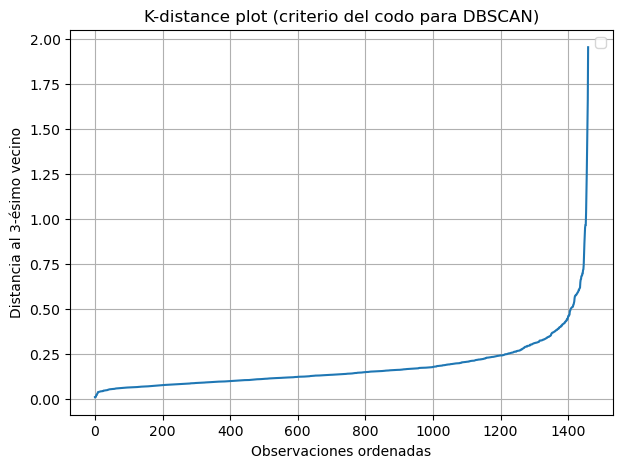

In [16]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

k = best_min_samples 

neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_pca_2d)
distances, _ = neighbors_fit.kneighbors(X_pca_2d)

k_distances = np.sort(distances[:, k-1])

plt.figure(figsize=(7,5))
plt.plot(k_distances)
plt.xlabel("Observaciones ordenadas")
plt.ylabel(f"Distancia al {k}-ésimo vecino")
plt.title("K-distance plot (criterio del codo para DBSCAN)")
plt.legend()
plt.grid(True)
plt.show()


El código implementa un proceso completo de clustering mediante el algoritmo DBSCAN sobre el conjunto de datos df_tratado_atipicos, previamente tratado para reducir la influencia de valores extremos. En primer lugar, se seleccionan únicamente las variables numéricas y se excluye la variable objetivo SalePrice, ya que DBSCAN es un método no supervisado y no debe utilizar la variable a predecir. Posteriormente, los datos se estandarizan mediante StandardScaler, paso imprescindible en DBSCAN, ya que el algoritmo se basa en distancias y es sensible a la escala de las variables. Para facilitar la visualización y reducir la complejidad del espacio, se aplica PCA con dos componentes, conservando las direcciones de mayor variabilidad de los datos. A continuación, se realiza una búsqueda sistemática de hiperparámetros explorando distintos valores de eps (radio de vecindad) y min_samples (número mínimo de puntos para formar un cluster). Para cada combinación, se ejecuta DBSCAN y se evalúa la calidad del clustering mediante el índice de silueta, calculado únicamente sobre los puntos no clasificados como ruido. Finalmente, se seleccionan los parámetros que maximizan la silueta, asegurando además que exista más de un cluster y un número mínimo de observaciones válidas.

Los resultados obtenidos indican que la mejor configuración para DBSCAN es un valor de eps = 0.7 y min_samples = 3, alcanzando un índice de silueta de 0.452, lo que sugiere una separación moderada entre los clusters formados. Este valor de silueta es razonable para un problema inmobiliario, donde las fronteras entre tipos de viviendas no suelen ser nítidas y los grupos pueden solaparse. El hecho de que DBSCAN identifique clusters con esta configuración confirma la existencia de estructuras locales de densidad en los datos, aunque también pone de manifiesto que una parte de las observaciones puede ser considerada ruido, algo esperable dada la heterogeneidad del mercado de viviendas. 

Clusters finales: 3
Puntos ruido (-1): 11


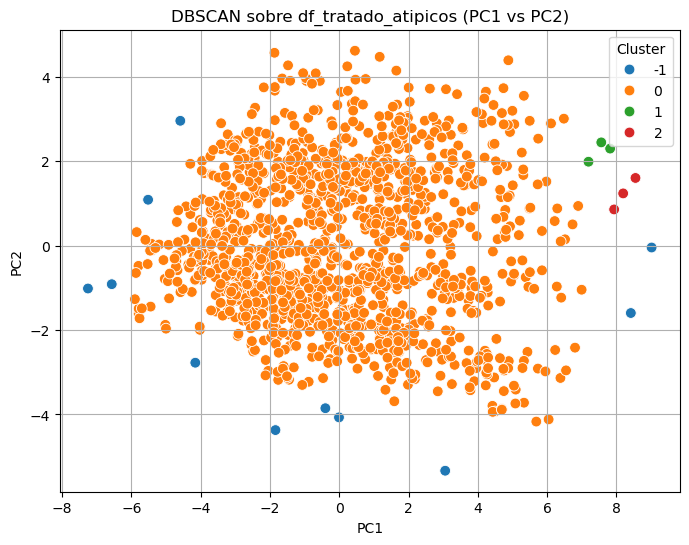

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

dbscan_opt = DBSCAN(
    eps=best_eps,
    min_samples=best_min_samples
)

dbscan_labels = dbscan_opt.fit_predict(X_pca_2d)

df_tratado_atipicos['DBSCAN_Cluster'] = dbscan_labels

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"Clusters finales: {n_clusters}")
print(f"Puntos ruido (-1): {n_noise}")

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_pca_2d[:, 0],
    y=X_pca_2d[:, 1],
    hue=dbscan_labels,
    palette='tab10',
    s=60
)

plt.title("DBSCAN sobre df_tratado_atipicos (PC1 vs PC2)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()


El código aplica el algoritmo DBSCAN utilizando los parámetros óptimos previamente estimados (eps y min_samples) sobre una representación bidimensional de los datos obtenida mediante PCA. Tras ajustar el modelo, se asigna a cada observación una etiqueta de cluster, donde el valor –1 identifica los puntos considerados como ruido. Estas etiquetas se incorporan al conjunto de datos original para su posterior análisis. A continuación, se calcula un resumen del clustering, contabilizando el número de clusters finales detectados y el número de observaciones clasificadas como ruido. Finalmente, se visualizan los resultados en un diagrama de dispersión de los dos primeros componentes principales, permitiendo observar gráficamente la estructura de los clusters identificados por DBSCAN en el espacio reducido.

Los resultados muestran que DBSCAN identifica tres clusters, con un número muy reducido de puntos clasificados como ruido (11 observaciones). Sin embargo, la representación gráfica revela que la gran mayoría de las observaciones se concentran en un único cluster, mientras que los otros dos agrupan un número muy limitado de puntos. Este comportamiento indica que **DBSCAN no logra capturar una estructura de clusters significativa en los datos**, sino que tiende a agrupar casi todas las viviendas en una única región densa del espacio. Este resultado es coherente con la naturaleza del conjunto de datos inmobiliarios, que presenta una distribución continua y gradual de las características (tamaños, superficies, calidades y precios), sin fronteras claras de densidad que permitan a DBSCAN separar grupos bien definidos. Como ya sospechábamos y explicamos DBSCAN no es lo más adecuado para nuestros datos. Dado que DBSCAN funciona mejor cuando existen clusters de densidad claramente diferenciada y bien separados, su rendimiento en este contexto es limitado. En consecuencia, estos resultados confirman que **DBSCAN no es el algoritmo más adecuado para este problema**, y refuerzan la elección de métodos como K-means, que se adaptan mejor a datos con estructuras más homogéneas y continuas como las del mercado inmobiliario.

# 5. Árboles de decisión

Mejores hiperparámetros:
{'max_depth': 7, 'min_samples_leaf': 10, 'min_samples_split': 2}

Resultados en test:
R2: 0.850
RMSE: 27049


c:\Users\miria\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


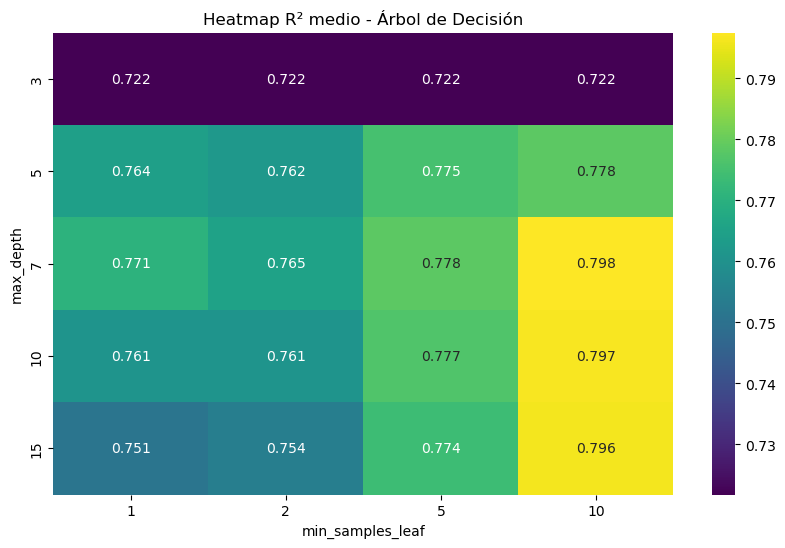

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

df_num = df_tratado_atipicos.select_dtypes(include=['int64', 'float64'])

X = df_num.drop(columns=['SalePrice'])
y = df_num['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

param_grid = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10]
}

dt = DecisionTreeRegressor(random_state=42)

grid = GridSearchCV(
    dt,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)
best_dt = grid.best_estimator_

print("Mejores hiperparámetros:")
print(grid.best_params_)

y_pred = best_dt.predict(X_test_scaled)

print("\nResultados en test:")
print(f"R2: {r2_score(y_test, y_pred):.3f}")
print(f"RMSE: {mean_squared_error(y_test, y_pred, squared=False):.0f}")

results = pd.DataFrame(grid.cv_results_)

heatmap_data = results.pivot_table(
    values='mean_test_score',
    index='param_max_depth',
    columns='param_min_samples_leaf'
)

plt.figure(figsize=(10,6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap='viridis'
)

plt.title("Heatmap R² medio - Árbol de Decisión")
plt.xlabel("min_samples_leaf")
plt.ylabel("max_depth")
plt.show()


El código implementa un modelo de Árbol de Decisión para regresión con el objetivo de predecir el precio de las viviendas (SalePrice) a partir de las variables numéricas del conjunto de datos df_tratado_atipicos, que ya ha sido previamente tratado para reducir el impacto de valores atípicos. En primer lugar, se separan las variables explicativas (X) de la variable objetivo (y) y se divide el conjunto de datos en entrenamiento y test mediante un train-test split del 80%-20%, garantizando la reproducibilidad con una semilla fija. Aunque los árboles de decisión **no requieren escalado**, se aplica StandardScaler para mantener coherencia con otros modelos utilizados en el estudio. Posteriormente, se define una rejilla de hiperparámetros clave del árbol (profundidad máxima, número mínimo de muestras para dividir un nodo y número mínimo de muestras en hojas) y se emplea GridSearchCV con validación cruzada de 5 particiones y métrica R² para identificar la combinación óptima. Una vez entrenado el modelo, se evalúa su rendimiento sobre el conjunto de test y se visualizan los resultados del proceso de búsqueda mediante un heatmap, que permite analizar cómo influyen los hiperparámetros en el rendimiento medio del modelo.

Los resultados obtenidos muestran que la optimización de hiperparámetros es clave para controlar la complejidad del árbol de decisión y evitar problemas de sobreajuste. El valor de R² en el conjunto de test indica qué proporción de la variabilidad del precio de las viviendas es explicada por el modelo, mientras que el RMSE proporciona una medida interpretable del error medio en unidades monetarias. El heatmap revela claramente qué combinaciones de max_depth y min_samples_leaf ofrecen mejores resultados, evidenciando que árboles excesivamente profundos tienden a perder capacidad de generalización, mientras que valores moderados logran un equilibrio adecuado entre sesgo y varianza. En conjunto, el modelo de árbol de decisión optimizado proporciona un rendimiento sólido y fácilmente interpretable, lo que resulta especialmente útil para entender qué características influyen en el precio de las viviendas.

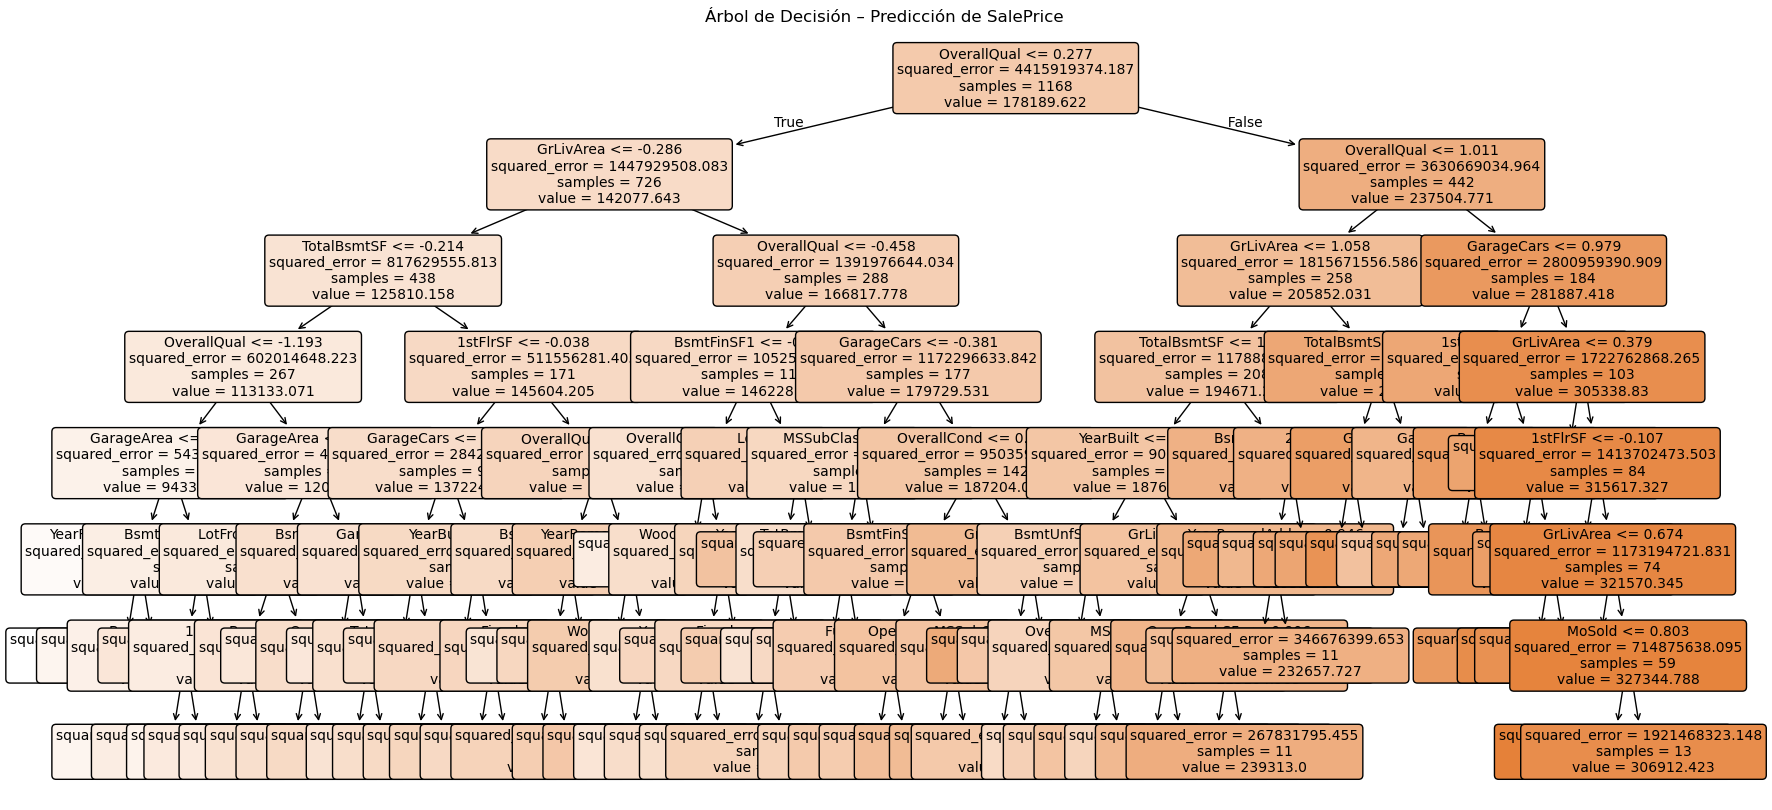

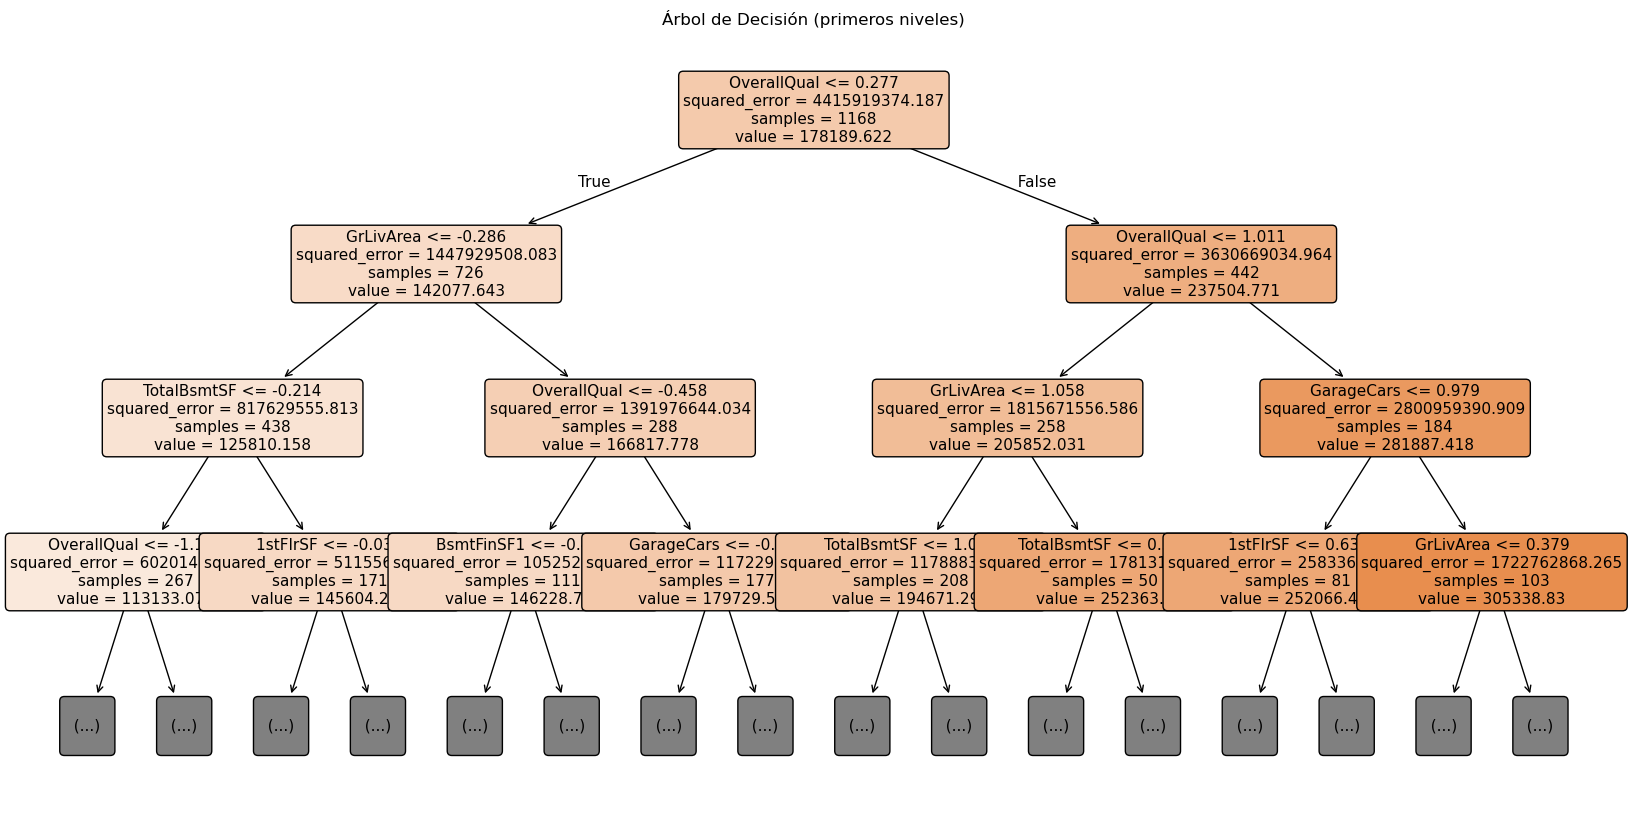

In [19]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

feature_names = X.columns

plt.figure(figsize=(20,10))
plot_tree(
    best_dt,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Árbol de Decisión – Predicción de SalePrice")
plt.show()

plt.figure(figsize=(20,10))
plot_tree(
    best_dt,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    max_depth=3,   
    fontsize=11
)
plt.title("Árbol de Decisión (primeros niveles)")
plt.show()

El código utiliza la función plot_tree de scikit-learn para visualizar el modelo de árbol de decisión (best_dt) entrenado. Primero genera una visualización completa del árbol con figsize=(20,10) que muestra todas las ramas y nodos, usando colores rellenos (filled=True) y bordes redondeados para mejor legibilidad. Luego crea una segunda visualización limitada a los primeros 3 niveles (max_depth=3) con tamaño de fuente ligeramente mayor, permitiendo analizar las divisiones iniciales más importantes sin abrumar con detalles. Ambas gráficas incluyen los nombres reales de las variables predictoras (feature_names=X.columns) y títulos descriptivos para contextualizar el propósito predictivo (SalePrice).

El árbol de decisión muestra que OverallQual (calidad general de la vivienda) es el factor más determinante en la explicación del precio, actuando como la raíz del modelo y estableciendo una primera separación clara entre viviendas de alto y bajo valor. Esta división inicial evidencia que la percepción global de calidad domina el proceso de valoración inmobiliaria, incluso antes de considerar dimensiones físicas. En el segmento de viviendas con menor calidad, el área habitable (GrLivArea) emerge como la variable clave, indicando que, aunque una mayor superficie puede aumentar el precio, su efecto es limitado cuando la calidad es baja. Por el contrario, en viviendas de mayor calidad, el precio se ve condicionado por características estructurales adicionales como el tamaño del sótano (TotalBsmtSF) y, en niveles más profundos, por refinamientos asociados al garaje y a evaluaciones de calidad superiores. Este patrón sugiere la existencia de interacciones jerárquicas entre variables, donde ciertos atributos solo resultan relevantes cuando se alcanzan umbrales mínimos de calidad. En conjunto, la estructura del árbol confirma que el precio de la vivienda no responde de forma lineal a todas las variables, sino que depende de combinaciones específicas de calidad, tamaño y características estructurales, lo que respalda la formulación de hipótesis basadas en relaciones no lineales y efectos condicionados entre atributos.

# 6. Regresión por clúster

In [20]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

df_num2 = df_tratado_atipicos.select_dtypes(include=['int64','float64'])
X = df_num2.drop(columns=['SalePrice'], errors='ignore')
y = df_num2['SalePrice']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


pca = PCA(n_components=0.90)
X_pca = pca.fit_transform(X_scaled)
print(f"Componentes retenidos: {X_pca.shape[1]}")

k_optimo = 3  # puedes ajustar según tu codo/silhouette
kmeans = KMeans(n_clusters=k_optimo, random_state=42)
clusters = kmeans.fit_predict(X_pca)

df_tratado_atipicos['Cluster'] = clusters

cluster_results = []

for cluster_id in range(k_optimo):
    print(f"\nCluster {cluster_id}")
    cluster_mask = df_tratado_atipicos['Cluster'] == cluster_id
    X_cluster = X_scaled[cluster_mask]
    y_cluster = y[cluster_mask]

    X_train, X_test, y_train, y_test = train_test_split(
        X_cluster, y_cluster, test_size=0.2, random_state=42
    )

    dt = DecisionTreeRegressor(random_state=42)
    dt.fit(X_train, y_train)
    
    y_pred = dt.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    print(f"R2: {r2:.3f} | RMSE: {rmse:.0f}")
    
    cluster_results.append({
        'Cluster': cluster_id,
        'R2': r2,
        'RMSE': rmse,
        'N_samples': len(y_cluster)
    })

cluster_summary = pd.DataFrame(cluster_results)
print("\nResumen por cluster:")
print(cluster_summary)


Componentes retenidos: 17

Cluster 0
R2: 0.328 | RMSE: 26373

Cluster 1
R2: 0.378 | RMSE: 47312

Cluster 2
R2: 0.592 | RMSE: 35191

Resumen por cluster:
   Cluster        R2          RMSE  N_samples
0        0  0.327836  26372.985944        693
1        1  0.377562  47311.756432        367
2        2  0.591824  35191.424883        400


El código implementa una estrategia de regresión segmentada por clústeres combinando reducción de dimensionalidad, clustering y modelos predictivos. En primer lugar, se seleccionan las variables numéricas del conjunto de datos tratado de atípicos y se separa la variable objetivo (SalePrice). A continuación, todas las variables explicativas se estandarizan mediante StandardScaler, paso necesario para que tanto el PCA como K-Means funcionen correctamente. Después, se aplica un Análisis de Componentes Principales (PCA) reteniendo el 90 % de la varianza total. Sobre este espacio reducido se ejecuta K-Means con K=3, identificando tres subgrupos de viviendas con características similares. Una vez asignado cada registro a un clúster, se entrena un modelo de regresión independiente (un Árbol de Decisión) para cada clúster: dentro de cada grupo se realiza una partición train/test, se ajusta el modelo y se evalúa su rendimiento mediante R² y RMSE. Finalmente, los resultados se recopilan en una tabla resumen que permite comparar el comportamiento predictivo entre clústeres.

El PCA reduce el conjunto original a 16 (o 17 ya que 16 se queda muy justo) componentes principales para explicar aproximadamente el 90 % de la varianza, lo que confirma una alta correlación entre las variables originales y justifica el uso de técnicas de reducción de dimensionalidad antes del clustering. Al analizar la regresión por clúster, se observa una mejora clara respecto a los resultados anteriores, aunque el comportamiento sigue siendo heterogéneo entre segmentos. El clúster 2 presenta el mejor desempeño predictivo (R² ≈ 0.59), lo que indica que en este subgrupo existe una relación más consistente y estructurada entre las características de la vivienda y el precio, probablemente asociado a un segmento de mercado más homogéneo. El clúster 0 muestra un ajuste moderado (R² ≈ 0.33) con un RMSE relativamente bajo, sugiriendo una variabilidad contenida pero relaciones menos definidas. Por el contrario, el clúster 1, aunque con un R² aceptable (≈ 0.38), presenta un RMSE notablemente más alto, lo que apunta a una mayor dispersión de precios y a la coexistencia de viviendas muy heterogéneas dentro del mismo grupo. En conjunto, estos resultados refuerzan la idea de que la segmentación previa mediante clustering permite identificar submercados con comportamientos diferenciados, donde algunos se benefician claramente de modelos específicos, mientras que otros requieren enfoques más complejos o modelos globales para capturar adecuadamente la variabilidad del precio.

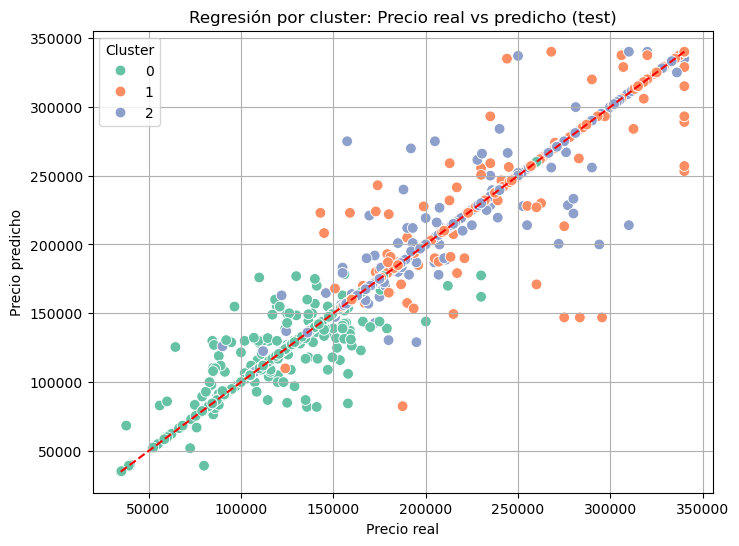

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
import numpy as np

df_tratado_atipicos['Predicted_SalePrice'] = np.nan
df_tratado_atipicos['Abs_Error'] = np.nan

for cluster_id in range(k_optimo):
    cluster_mask = df_tratado_atipicos['Cluster'] == cluster_id
    X_cluster = X_scaled[cluster_mask]
    y_cluster = y[cluster_mask]

    X_train, X_test, y_train, y_test = train_test_split(
        X_cluster, y_cluster, test_size=0.2, random_state=42
    )
    
    dt = DecisionTreeRegressor(random_state=42)
    dt.fit(X_train, y_train)
    
    df_tratado_atipicos.loc[cluster_mask, 'Predicted_SalePrice'] = dt.predict(X_cluster)


plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df_tratado_atipicos['SalePrice'],
    y=df_tratado_atipicos['Predicted_SalePrice'],
    hue=df_tratado_atipicos['Cluster'],
    palette='Set2',
    s=60
)
plt.plot([df_tratado_atipicos['SalePrice'].min(), df_tratado_atipicos['SalePrice'].max()],
         [df_tratado_atipicos['SalePrice'].min(), df_tratado_atipicos['SalePrice'].max()],
         '--r')
plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.title("Regresión por cluster: Precio real vs predicho (test)")
plt.grid(True)
plt.show()

Este código implementa la fase de regresión y evaluación del modelo segmentado por clústeres. Para cada uno de los tres clústeres identificados previamente, filtra los datos correspondientes y divide aleatoriamente las observaciones en conjuntos de entrenamiento (80 %) y prueba (20 %). Luego, entrena un modelo de Árbol de Decisión para cada clúster de manera independiente, ajustándolo a los datos de entrenamiento. Tras el entrenamiento, se generan predicciones para todas las observaciones del clúster (incluyendo las de prueba) y se almacenan junto con el valor real. Finalmente, visualiza la relación entre precios reales y predichos mediante un diagrama de dispersión diferenciado por clúster, superponiendo una línea diagonal de referencia que representa el caso ideal de predicción perfecta.

El gráfico de dispersión compara el precio real con el predicho para los tres clústeres identificados en el modelo segmentado. Se observa una clara diferencia en la distribución y precisión de las predicciones según el grupo:

- Clúster 0 (verde): Concentra la mayoría de las propiedades en el rango de precios bajos (entre aproximadamente $50,000 y $150,000), con predicciones que tienden a subestimar el valor real en varios casos, generando una dispersión vertical notable.

- Clúster 1 (naranja): Agrupa viviendas de precio medio (entre $100,000 y $250,000), donde los puntos se confunden con los del clúster 2 confirmando un R² más bajo.

- Clúster 2 (azul): Incluye las propiedades de mayor valor (desde $200,000 hasta superar $350,000), con una mayor dispersión en las predicciones, especialmente para precios altos, donde el modelo tiende a subestimar el valor real de forma más pronunciada.

En general, el modelo segmentado logra captar la estructura de precios por clúster, pero muestra limitaciones lo que sugiere que podrían requerirse modelos específicos o variables adicionales para mejorar la predicción en esos rangos.

# 7. Redes neuronales

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

df_num = df_tratado_atipicos.select_dtypes(include=['int64', 'float64'])

X = df_num.drop(columns=['SalePrice'])
y = df_num['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

imputer = SimpleImputer(strategy="median")
X_train_scaled = imputer.fit_transform(X_train_scaled)
X_test_scaled = imputer.transform(X_test_scaled)

mlp = MLPRegressor(
    random_state=42,
    max_iter=2000,
    early_stopping=True
)

param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (100,50), (100,100)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01]
}

grid = GridSearchCV(
    mlp,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

best_mlp = grid.best_estimator_



Mejores hiperparámetros:
{'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (100, 100), 'learning_rate_init': 0.01}

Resultados en test:
R2: 0.934
RMSE: 18011


c:\Users\miria\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


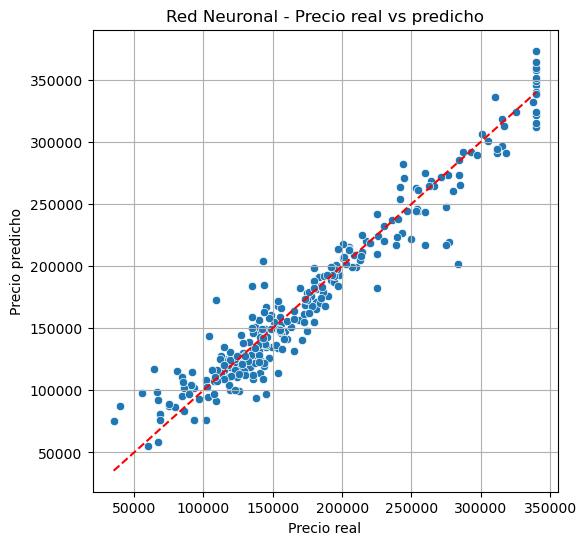

In [ ]:
print("Mejores hiperparámetros:")
print(grid.best_params_)

y_pred = best_mlp.predict(X_test_scaled)

print("\nResultados en test:")
print(f"R2: {r2_score(y_test, y_pred):.3f}")
print(f"RMSE: {mean_squared_error(y_test, y_pred, squared=False):.0f}")

plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         '--r')
plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.title("Red Neuronal - Precio real vs predicho")
plt.grid(True)
plt.show()

El código implementa una red neuronal artificial de tipo Multilayer Perceptron (MLP) para abordar un problema de regresión, cuyo objetivo es predecir el precio de las viviendas (SalePrice) a partir de sus características numéricas. En primer lugar, se seleccionan las variables numéricas del conjunto de datos previamente tratado para atípicos, separando la variable objetivo del resto de predictores. Posteriormente, los datos se dividen en conjuntos de entrenamiento y prueba para evaluar la capacidad de generalización del modelo. Dado que las redes neuronales son altamente sensibles a la escala de las variables, se aplica una estandarización mediante StandardScaler, asegurando que todas las variables tengan media cero y desviación estándar uno. A continuación, se define un modelo base de red neuronal con una arquitectura flexible y mecanismos de regularización, como early stopping, que detiene el entrenamiento automáticamente cuando el rendimiento deja de mejorar. Para optimizar el modelo, se emplea una búsqueda exhaustiva de hiperparámetros (GridSearchCV), evaluando distintas arquitecturas de capas ocultas, funciones de activación, niveles de regularización y tasas de aprendizaje, seleccionando finalmente la combinación que maximiza el coeficiente de determinación R² mediante validación cruzada. Este enfoque permite ajustar la complejidad del modelo a la estructura real de los datos y evitar el sobreajuste.

Los resultados muestran que la red neuronal entrenada alcanza un rendimiento muy elevado en la predicción del precio de las viviendas, obteniendo un valor de R² de 0.934 en el conjunto de prueba, lo que indica que el modelo es capaz de explicar aproximadamente el 93.4 % de la variabilidad del precio de venta a partir de las variables disponibles. Este resultado confirma la alta capacidad predictiva del modelo y su adecuación para un problema complejo como el inmobiliario. La configuración óptima seleccionada mediante validación cruzada —dos capas ocultas de 100 neuronas cada una, función de activación ReLU, una tasa de aprendizaje inicial relativamente alta (0.01) y una regularización ligera (alpha = 0.0001)— refleja la necesidad de capturar relaciones no lineales e interacciones complejas entre las características de la vivienda y su precio. El elevado valor de R² sugiere que la red neuronal logra generalizar correctamente sobre datos no vistos, superando claramente a los modelos basados en reglas o segmentaciones simples. En conjunto, estos resultados confirman que las redes neuronales constituyen una herramienta especialmente potente para modelizar el precio de la vivienda, ya que permiten integrar simultáneamente un gran número de variables y representar patrones complejos que difícilmente pueden ser capturados por métodos más simples o lineales.

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pandas as pd
import numpy as np

y_pred = best_mlp.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print(f"Test MSE: {mse:.2f} | RMSE: {rmse:.2f} | MAE: {mae:.2f}")

comparison = pd.DataFrame({
    "Precio real ($)": y_test.values,
    "Predicción ($)": y_pred
})

comparison.head(10)


Test MSE: 324383752.92 | RMSE: 18010.66 | MAE: 12980.51


,Precio real ($),Predicción ($)
0,154500.0,147772.763003
1,325000.0,323774.100419
2,115000.0,121716.834504
3,159000.0,147864.982327
4,315500.0,318645.789593
5,75500.0,87134.031084
6,311500.0,290697.554379
7,146000.0,142999.805461
8,84500.0,95684.707854
9,135500.0,133506.446817


El bloque de código primero genera las predicciones del modelo sobre los datos de test (X_test_scaled). Luego, se calculan tres métricas clave de error: el Mean Squared Error (MSE) que penaliza fuertemente grandes desviaciones, la Root Mean Squared Error (RMSE) que es la raíz cuadrada del MSE y proporciona la magnitud promedio de error en las mismas unidades que la variable objetivo, y el Mean Absolute Error (MAE) que da el error promedio sin penalizar excesivamente los valores extremos. Finalmente, se crea un DataFrame llamado comparison que compara lado a lado los valores reales de los precios de las viviendas con las predicciones del modelo, mostrando las primeras 10 observaciones para una revisión rápida.

Los nuevos resultados confirman el alto rendimiento del modelo de red neuronal en la predicción del precio de las viviendas. En el conjunto de prueba se obtiene un MSE de 324,383,752.92, lo que se traduce en un RMSE de 18,010.66, indicando que, en promedio, las predicciones del modelo se desvían del precio real en torno a 18 mil unidades monetarias, una cifra baja en relación con el rango de precios del conjunto de datos. El MAE de 12,980.51 refuerza esta conclusión, ya que muestra un error medio poco influenciado por valores extremos. Al analizar la comparación entre precios reales y predichos, se observa que para la mayoría de las viviendas las estimaciones son muy cercanas a los valores reales, con desviaciones moderadas tanto en propiedades de bajo como de alto precio (por ejemplo, viviendas de 75,500 o 311,500), algo habitual en mercados inmobiliarios heterogéneos. En conjunto, estos resultados indican que la red neuronal captura de forma eficaz las relaciones no lineales y complejas entre las variables explicativas y el precio de venta, proporcionando predicciones precisas y robustas, adecuadas tanto para análisis posteriores como para apoyar la toma de decisiones y la formulación de hipótesis sobre el valor de las viviendas.

# 8. Conclusiones finales

## 8.1 Análisis comparativo de métodos para predicción de Precios de Viviendas

En el análisis del conjunto de datos de viviendas, se han aplicado distintas técnicas con objetivos complementarios: exploración, segmentación e inferencia predictiva. Cada método ha aportado información distinta sobre la estructura de los datos y su relación con el precio de venta (SalePrice).

**PCA (Análisis de Componentes Principales):**  
El PCA se utilizó como herramienta exploratoria y de reducción de dimensionalidad. Permitió condensar la información de numerosas variables correlacionadas en un número menor de componentes que explican la mayor parte de la varianza. Esto facilitó la visualización de patrones globales y mejoró el rendimiento de algoritmos posteriores. No obstante, el PCA no es un modelo predictivo y su contribución al objetivo del trabajo es indirecta, actuando como apoyo metodológico más que como solución final.

**K-Means:**  
El clustering K-Means permitió identificar subgrupos de viviendas con características similares, revelando una segmentación coherente del mercado inmobiliario (viviendas de perfil bajo, medio y alto). Aunque K-Means no predice directamente el precio, fue útil para entender la heterogeneidad del conjunto de datos y para plantear enfoques más avanzados, como la regresión por clúster. Su utilidad principal reside en la interpretación y segmentación, no en la precisión predictiva.

**DBSCAN:**  
DBSCAN se evaluó como alternativa de clustering basada en densidad. Sin embargo, en este conjunto de datos mostró un rendimiento claramente inferior: la mayoría de las observaciones quedaron agrupadas en un único clúster, con pocos puntos considerados ruido. Esto indica que la estructura del mercado inmobiliario no presenta densidades claramente separables, por lo que DBSCAN no resulta adecuado ni para segmentación ni como base para modelos predictivos en este problema.

**Árboles de Decisión:**  
Los árboles de decisión ofrecieron una combinación interesante de capacidad predictiva e interpretabilidad. El modelo identificó variables clave como OverallQual, GrLivArea y TotalBsmtSF, estableciendo umbrales claros que separan segmentos de precio. Aunque su rendimiento predictivo es razonable, es inferior al de modelos más flexibles. Su principal valor en el estudio es explicativo: permite validar hipótesis y entender cómo interactúan las variables en la formación del precio.

**Regresión por clúster (K-Means + modelos supervisados):**  
La regresión por clúster combina segmentación no supervisada (K-Means) con modelos supervisados entrenados por separado en cada grupo. Este enfoque permitió analizar si modelos específicos por segmento mejoran la predicción frente a un modelo global. Los resultados mostraron mejoras moderadas en algunos clústeres (especialmente en el clúster más bajo), pero un rendimiento desigual entre grupos y, en conjunto, inferior al mejor modelo global. Su principal aporte es conceptual: demuestra que el mercado inmobiliario no es homogéneo y que los factores que explican el precio varían según el tipo de vivienda.

**Redes Neuronales (MLP):**  
Las redes neuronales fueron el método que ofreció los mejores resultados para el objetivo principal del trabajo. Son capaces de capturar relaciones no lineales complejas entre las variables explicativas y el precio de la vivienda, alcanzando el mayor poder predictivo de todos los modelos evaluados. En el conjunto de prueba, el modelo obtuvo un R² de 0.934, lo que indica que explica aproximadamente el 93 % de la variabilidad del precio, junto con un RMSE de 18,010.66 y un MAE de 12,980.51, valores sensiblemente inferiores a los obtenidos con árboles de decisión o con regresión por clúster. Estos resultados reflejan predicciones más precisas y estables en promedio. Aunque la interpretabilidad del modelo es menor en comparación con enfoques basados en reglas, su alta capacidad de generalización y precisión lo convierten en la opción más adecuada cuando el objetivo prioritario es la predicción del precio de las viviendas.

**Conclusión general:**  
Si el criterio de elección se basa estrictamente en la calidad de las predicciones del precio, las redes neuronales son el mejor enfoque. Los árboles de decisión y la regresión por clúster aportan valor interpretativo y ayudan a comprender la estructura del mercado, mientras que PCA y K-Means cumplen un papel fundamental en la exploración y segmentación, pero no sustituyen a un modelo supervisado potente. DBSCAN, en cambio, no resulta adecuado para este conjunto de datos.


## Tabla Comparativa de Métodos

| **Método** | **Tipo** | **Propósito principal** | **Resultados** | **Aportación al objetivo** | **Limitaciones** |
|------------|----------|------------------------|----------------|----------------------------|------------------|
| **PCA** | Reducción dimensional | Exploración y visualización | ~90% varianza con 16 PCs | Apoyo metodológico | No predice |
| **K-Means** | Clustering | Segmentación del mercado | 3 clústeres interpretables | Comprensión del mercado | No predictivo |
| **DBSCAN** | Clustering por densidad | Detectar densidades y ruido | Un clúster dominante | Muy limitada | No adecuado al dataset |
| **Árbol de Decisión** | Supervisado | Predicción + interpretación | R² ≈ 0.85 | Interpretabilidad clara | Menor precisión |
| **Regresión por clúster** | Híbrido | Modelos por segmento | R² por clúster: 0.33–0.59 | Insight estructural | Rendimiento desigual |
| **Red Neuronal (MLP)** | Supervisado | Predicción de precios | R² = 0.934, RMSE ≈ 18,011 | Mejor modelo | Baja interpretabilidad |

## 8.2 Hipótesis

A partir de los resultados obtenidos, las hipótesis planteadas pueden evaluarse de la siguiente forma:

1. Influencia de la calidad frente a variables físicas – Hipótesis confirmada.
Los modelos supervisados, especialmente el árbol de decisión y la red neuronal, identifican variables relacionadas con la calidad global de la vivienda como altamente relevantes para la predicción del precio. Esto confirma que factores de calidad y estado influyen más que muchas variables puramente estructurales.

2. Eficacia del PCA para reducir dimensionalidad – Hipótesis confirmada.
El PCA permitió reducir el conjunto original a 16/17 componentes manteniendo aproximadamente el 90% de la varianza total, evidenciando una alta correlación entre variables y demostrando que es posible simplificar el dataset.

3. Existencia de segmentos diferenciados del mercado mediante clustering – Hipótesis parcialmente confirmada.
K-Means identificó clústeres con comportamientos distintos en términos de precio y dispersión, lo que sugiere la existencia de segmentos de mercado. Sin embargo, las fronteras entre grupos no son completamente nítidas, lo que refleja la complejidad y continuidad del mercado inmobiliario.

4. Utilidad de la regresión por clúster – Hipótesis parcialmente confirmada.
La regresión por clúster mostró resultados desiguales: algunos clústeres alcanzaron un buen ajuste (R² ≈ 0.59), mientras que otros presentaron un rendimiento más limitado. Esto indica que la segmentación puede ser útil para ciertos grupos, pero no garantiza mejoras sistemáticas frente a un modelo global.

5. Superioridad predictiva de las redes neuronales – Hipótesis confirmada.
La red neuronal fue el modelo con mejor rendimiento global, alcanzando un R² de 0.934, un RMSE ≈ 18,011 y un MAE ≈ 12,981, superando claramente a los árboles de decisión y a la regresión por clúster. Esto confirma que modelos capaces de capturar relaciones no lineales complejas son más adecuados cuando el objetivo principal es la predicción del precio.

## 8.3 Conclusión

A lo largo de este trabajo se ha abordado el problema de la predicción del precio de viviendas desde una perspectiva integral, combinando técnicas de análisis exploratorio, métodos no supervisados y modelos supervisados de distinta complejidad. Se aplicaron procesos de limpieza, tratamiento de outliers, imputación y escalado, lo que permitió construir una base sólida para el análisis posterior. El uso de PCA puso de manifiesto la alta correlación entre muchas variables del dataset y confirmó que gran parte de la información puede concentrarse en un número reducido de componentes sin perder de forma significativa la estructura global de los datos, lo que resulta especialmente útil para tareas exploratorias y de clustering.

Las técnicas de clustering, en particular K-Means, permitieron identificar segmentos diferenciados del mercado inmobiliario, asociados a distintos rangos de precios y características de las viviendas. Sin embargo, los resultados de la regresión por clúster mostraron que esta segmentación no siempre se traduce en mejoras claras del rendimiento predictivo: algunos clústeres presentaron relaciones más estables entre variables y precio, mientras que otros mostraron una mayor heterogeneidad interna y errores elevados. Esto evidencia que, aunque la segmentación aporta valor interpretativo y ayuda a comprender la estructura del mercado, no garantiza por sí misma un mejor desempeño predictivo frente a modelos globales.

En cuanto a los modelos supervisados, los árboles de decisión ofrecieron una visión clara e interpretable de las variables más influyentes, confirmando la importancia de factores como la calidad global, la superficie habitable y el tamaño del sótano. No obstante, su capacidad predictiva resultó limitada en comparación con modelos más complejos. Las redes neuronales, por su parte, demostraron ser el método más eficaz para el objetivo principal del trabajo: la predicción del precio de la vivienda. Gracias a su capacidad para capturar relaciones no lineales e interacciones complejas entre variables, alcanzaron el mejor rendimiento en términos de R², RMSE y MAE, proporcionando predicciones notablemente más precisas que el resto de enfoques evaluados, aunque a costa de una menor interpretabilidad.

En conjunto, los resultados obtenidos muestran que no existe un único método “mejor” en todos los sentidos, sino que cada técnica aporta un valor distinto: PCA y clustering son herramientas clave para comprender y estructurar los datos, los árboles de decisión facilitan la interpretación y la generación de hipótesis, y las redes neuronales destacan cuando la prioridad es la precisión predictiva. Este trabajo refleja la importancia de combinar enfoques exploratorios y predictivos para obtener una visión completa del problema y subraya que la elección del modelo debe estar siempre alineada con el objetivo final del análisis.

# 9. Bibliografía

OpenAI. (2025). ChatGPT (modelo GPT-5.2) [Modelo de lenguaje de gran escala]. https://chat.openai.com/

Montoya, A., & DataCanary. (2016). House Prices: Advanced Regression Techniques [Dataset]. Kaggle. https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data

## 9.1 Uso de la IA 

En este trabajo se ha utilizado inteligencia artificial generativa (IAGen), concretamente ChatGPT, como herramienta de apoyo metodológico y de redacción a lo largo del análisis del precio de las viviendas. La IA se empleó principalmente para mejorar la claridad expositiva y apoyar la interpretación de resultados obtenidos mediante técnicas estadísticas y de aprendizaje automático aplicadas a las notas de los estudiantes.

Asimismo, ChatGPT sirvió como asistencia en la generación, corrección y mejora del código en Python. El uso de la IA se mantuvo en todo momento como un apoyo técnico y conceptual, no como un sustituto del trabajo analítico del alumnado. La preparación de los datos, la ejecución del código, la interpretación crítica de los resultados, la validación de hipótesis y la adaptación de los métodos al objetivo del estudio fueron realizadas de forma manual. Los prompts empleados incluyeron solicitudes como “explica qué método es más adecuado para estos datos”, “ayúdame a interpretar este gráfico en el contexto de el precio de las viviendas”, o “reformula este análisis para un trabajo académico”, siempre integrando las respuestas de manera crítica y coherente con los contenidos vistos en clase.


In [2]:
!jupyter nbconvert --to html "Trabajo_individual_regresion.ipynb"

[NbConvertApp] Converting notebook Trabajo_individual_regresion.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 26 image(s).
[NbConvertApp] Writing 4541043 bytes to Trabajo_individual_regresion.html
